<a href="https://colab.research.google.com/github/m-rafiul-islam/student-learning-analytics-lab/blob/main/OULAD_Activity_Capstone_Project_SP26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project1: Student Learning Analytics
Predicting College Student
Performance
using Machine
Learning Techniques****

# Abstract ****

This project analyzes the Open University Learning Analytics Dataset (OULAD) to investigate how student behavior, engagement, and background characteristics relate to academic performance in online learning environments. The study combines exploratory data analysis, behavioral analysis, pathway analysis, demographic analysis, time-based engagement patterns, and machine learning techniques to better understand student success and risk. Early-course engagement and assessment features were constructed to support realistic prediction tasks. Multiple machine learning models were compared for both multiclass prediction of final outcomes and binary early warning classification. The results show that student outcomes can be predicted with reasonable accuracy using early behavioral and academic signals, with the strongest predictors coming from early assessment performance and VLE engagement. These findings highlight the value of learning analytics for early intervention, student support, and data-driven decision-making in online education.

# Introduction ****

Online education platforms generate large amounts of student interaction data. Understanding how students engage with course materials can help identify patterns that lead to academic success or failure.

This project analyzes the Open University Learning Analytics Dataset (OULAD) to explore how student behavior, engagement, and background characteristics influence academic outcomes.

The analysis focuses on multiple dimensions, including engagement behavior in the virtual learning environment, assessment performance, learning pathways, demographic differences, time-based activity patterns, and predictive modeling.

The main goal is to uncover actionable insights that can support early intervention and improve student success rates in online learning environments.

# Dataset Description ****

The dataset used in this project is the Open University Learning Analytics Dataset (OULAD), which contains anonymized data about students, courses, assessments, and interactions with the virtual learning environment.

The dataset includes:
- student demographic information such as gender, age band, region, and highest education level
- assessment records including type, submission date, and score
- clickstream data from the VLE showing how students interact with digital resources
- course and presentation information such as module code and module length

Each student is associated with one final outcome:
- Distinction
- Pass
- Fail
- Withdrawn

Because the dataset combines background information, performance data, and behavioral activity, it is well suited for both exploratory analysis and predictive modeling.

Open University Learning Analytics dataset

https://www.nature.com/articles/sdata2017171  



Github: Analysis of OULAD dataset

https://sergiosim.github.io/OULAD/intro.html

## Get the data from online

https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset

https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip

In [ ]:
!wget "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
!unzip data_oulad.zip -d data_oulad

--2026-04-17 02:16:43--  https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data_oulad.zip’

data_oulad.zip          [             <=>    ]  44.58M  12.0MB/s    in 3.7s    

2026-04-17 02:16:48 (12.0 MB/s) - ‘data_oulad.zip’ saved [46748244]

Archive:  data_oulad.zip
  inflating: data_oulad/assessments.csv  
  inflating: data_oulad/courses.csv  
  inflating: data_oulad/studentAssessment.csv  
  inflating: data_oulad/studentInfo.csv  
  inflating: data_oulad/studentRegistration.csv  
  inflating: data_oulad/studentVle.csv  
  inflating: data_oulad/vle.csv      
  inflating: data_oulad/OULAD.names  


## Data Cleaning and Processing ****

Before analysis, the dataset is cleaned and prepared by loading the relevant files, checking the available tables and variables, converting invalid values such as `?` into missing values, converting important columns into numeric format, and merging related tables for analysis.

This step ensures that the data is consistent and suitable for visualization, interpretation, and machine learning.

In [ ]:
import os
files = os.listdir('/content/data_oulad')
print(files)
print(f'There are {len(files)} in the oulad data folder.')
csv_files = [file for file in files if file.endswith('.csv')]
print(f'csv files: {csv_files}')
print(f'There are {len(csv_files)} in the oulad data folder.')

['vle.csv', 'studentVle.csv', 'assessments.csv', 'OULAD.names', 'studentRegistration.csv', 'studentInfo.csv', 'courses.csv', 'studentAssessment.csv']
There are 8 in the oulad data folder.
csv files: ['vle.csv', 'studentVle.csv', 'assessments.csv', 'studentRegistration.csv', 'studentInfo.csv', 'courses.csv', 'studentAssessment.csv']
There are 7 in the oulad data folder.


In [ ]:
# Read the OULAD.names file using with open() with a compatible encoding
with open('/content/data_oulad/OULAD.names', encoding='latin-1') as f:
    print(f.read())

1. Title of Database: Open University Learning Analytics dataset

2. Sources:

   (a) Original owners of database:
  The Open University
  Walton Hall, Milton Keynes
  MK7 6AA
  United Kingdom
  contact: Zdenek Zdrahal (zdenek.zdrahal@open.ac.uk)

   (b) Donor of database:
  Jakub Kuzilek (jakub.kuzilek@gmail.com)
  Knowledge Media Institute, The Open University
  Walton Hall, Milton Keynes, MK7 6AA, UK
  CIIRC, CTU in Prague
  Zikova 1903/4, Prague, CZ
  Martin Hlosta (martin.hlosta@open.ac.uk)
  Knowledge Media Institute, The Open University
  Walton Hall, Milton Keynes, MK7 6AA, UK
  Zdenek Zdrahal (zdenek.zdrahal@open.ac.uk)
  Knowledge Media Institute, The Open University
  Walton Hall, Milton Keynes, MK7 6AA, UK
  CIIRC, CTU in Prague
  Zikova 1903/4, Prague, CZ

   (c) Date received: December 2015


3. Past Usage:
  - none -

4. Relevant Information Paragraph:

    Open University Learning Analytics Dataset (OULAD) contains data about 
    courses, students and their interaction

In [ ]:
import pandas as pd

imd_band—the IMD band of the place where the student lived during the module-presentation.



In [ ]:
assessments = pd.read_csv('/content/data_oulad/assessments.csv')
assessments.tail(25)


,code_module,code_presentation,id_assessment,assessment_type,date,weight
181,GGG,2013J,37423,CMA,229,0.0
182,GGG,2013J,37415,TMA,61,0.0
183,GGG,2013J,37416,TMA,124,0.0
184,GGG,2013J,37417,TMA,173,0.0
185,GGG,2013J,37424,Exam,229,100.0
186,GGG,2014B,37428,CMA,222,0.0
187,GGG,2014B,37429,CMA,222,0.0
188,GGG,2014B,37430,CMA,222,0.0
189,GGG,2014B,37431,CMA,222,0.0
190,GGG,2014B,37432,CMA,222,0.0


In [ ]:
assessments['assessment_type'].unique()

array(['TMA', 'Exam', 'CMA'], dtype=object)

In [ ]:
assessments['weight'].unique().sum()

np.float64(401.5)

In [ ]:
assessments['code_module'].unique()

array(['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG'], dtype=object)

In [ ]:
courses = pd.read_csv('/content/data_oulad/courses.csv')
courses.tail(2)

,code_module,code_presentation,module_presentation_length
20,GGG,2014J,269
21,GGG,2014B,241


In [ ]:
studentAssessment = pd.read_csv('/content/data_oulad/studentAssessment.csv')
studentAssessment.tail(5)

,id_assessment,id_student,date_submitted,is_banked,score
173907,37443,527538,227,0,60
173908,37443,534672,229,0,100
173909,37443,546286,215,0,80
173910,37443,546724,230,0,100
173911,37443,558486,224,0,80


In [ ]:
studentInfo = pd.read_csv('/content/data_oulad/studentInfo.csv')
studentInfo.tail(5)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn
32592,GGG,2014J,2684003,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Distinction


In [ ]:
studentRegistration = pd.read_csv('/content/data_oulad/studentRegistration.csv')
studentRegistration.tail(5)

,code_module,code_presentation,id_student,date_registration,date_unregistration
32588,GGG,2014J,2640965,-4,?
32589,GGG,2014J,2645731,-23,?
32590,GGG,2014J,2648187,-129,?
32591,GGG,2014J,2679821,-49,101
32592,GGG,2014J,2684003,-28,?


In [ ]:
studentVle = pd.read_csv('/content/data_oulad/studentVle.csv')
studentVle.tail(5)

,code_module,code_presentation,id_student,id_site,date,sum_click
10655275,GGG,2014J,675811,896943,269,3
10655276,GGG,2014J,675578,896943,269,1
10655277,GGG,2014J,654064,896943,269,3
10655278,GGG,2014J,654064,896939,269,1
10655279,GGG,2014J,654064,896939,269,1


In [ ]:
studentVle['sum_click'].value_counts().head(100)

,count
sum_click,
1,5113910
2,1929023
3,965277
4,612858
5,415139
...,...
95,303
98,253
97,249


In [ ]:
vle = pd.read_csv('/content/data_oulad/vle.csv')
vle.head(200)

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,?,?
1,546712,AAA,2013J,oucontent,?,?
2,546998,AAA,2013J,resource,?,?
3,546888,AAA,2013J,url,?,?
4,547035,AAA,2013J,resource,?,?
...,...,...,...,...,...,...
195,546653,AAA,2013J,forumng,?,?
196,546907,AAA,2013J,resource,?,?
197,546955,AAA,2013J,resource,?,?
198,546719,AAA,2013J,oucontent,1,1


## Data Cleaning and Processing
- Data Source

## Feature Engineering ****

To make the dataset more useful for analysis, several new variables are created from the original data.

These features summarize student engagement and performance, such as total clicks, average clicks, number of active days, and assessment statistics.

This step transforms raw interaction data into meaningful indicators that can be used for analysis and modeling.

## Exploratory Data Analysis (EDA)
- Statistics
- Graphs
- bar chart
- histogram
- box plot
- pair plot
- Identity trends from the data and make story

## Exploratory Data Analysis (EDA)**** (optional insead of the one above with bullet points?)

This section explores the structure and distribution of the dataset using statistical summaries and visualizations.

The goal is to identify patterns, trends, and relationships between variables before moving to deeper analysis.

## Behavior-Based Dropout Prediction
Instead of looking at "if" a student dropped out, focus on "when" and "how" their behavior changed before doing so.

Clickstream Velocity: Analyze the frequency and intensity of interactions in the weeks leading up to a withdrawal.

Early Warning Systems: Use the first 20–30% of a course duration to predict the final outcome. This is highly actionable for educators who want to intervene early.

## Figure: Student Engagement Analysis

## Student Engagement Analysis ****

This section examines how student engagement in the virtual learning environment varies across academic outcomes.

The focus is on click activity, participation levels, and how engagement relates to student success or failure.

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
# The original error was FileNotFoundError because 'student_behavior_data.csv' does not exist.
# We will use the available OULAD dataset files and merge them to create the required DataFrame.

# Load student information
df_info = pd.read_csv('/content/data_oulad/studentInfo.csv')

# Load student VLE interactions
df_vle = pd.read_csv('/content/data_oulad/studentVle.csv')

# Aggregate total clicks for each student
student_total_clicks = df_vle.groupby('id_student')['sum_click'].sum().reset_index()
student_total_clicks.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

# Merge student information with total clicks
df = pd.merge(df_info, student_total_clicks, on='id_student', how='inner')


sns.set_theme(context= 'talk')
# 1. Bar Chart: Count of Final Results
plt.figure()
sns.countplot(data=df, x='final_result',
              order=['Distinction', 'Pass', 'Fail', 'Withdrawn'],
              palette='viridis')
plt.title('Distribution of Student Final Results')
plt.xlabel('Final Result')
plt.ylabel('Count of Students')
plt.savefig('bar_chart_results.png')
plt.show() # Added to display the plot


/tmp/ipykernel_3186/3019275673.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='final_result',


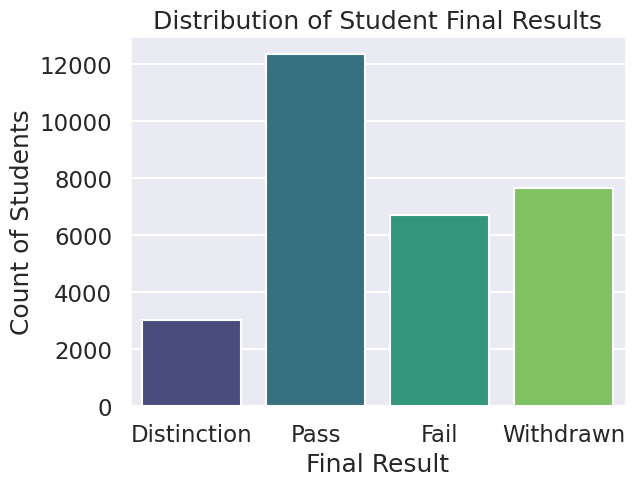

In [ ]:
sns.set_theme(context= 'talk')
# 1. Bar Chart: Count of Final Results
plt.figure()
sns.countplot(data=df, x='final_result',
              order=['Distinction', 'Pass', 'Fail', 'Withdrawn'],
              palette='viridis')
plt.title('Distribution of Student Final Results')
plt.xlabel('Final Result')
plt.ylabel('Count of Students')
plt.savefig('bar_chart_results.png')
plt.show() # Added to display the plot

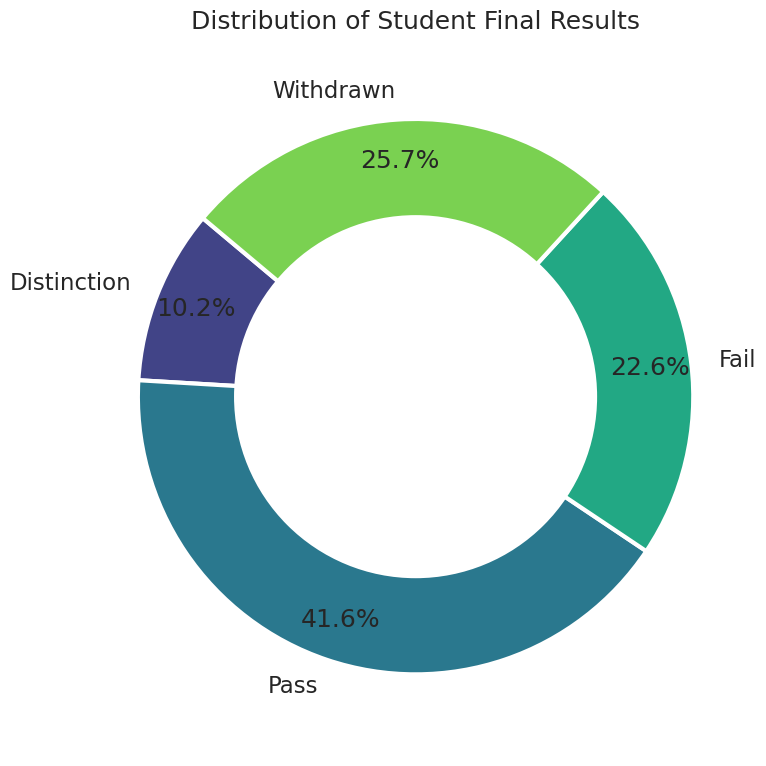

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the theme context to 'talk' to match your bar chart
sns.set_theme(context='talk')

# 1. Prepare the data
# We get counts in the specific order you used for the bar chart
data_counts = df['final_result'].value_counts().reindex(['Distinction', 'Pass', 'Fail', 'Withdrawn'])
labels = data_counts.index
sizes = data_counts.values

# 2. Define Seaborn colors
colors = sns.color_palette('viridis', n_colors=len(labels))

# 3. Create the Plot
plt.figure(figsize=(8, 8))

# Create the pie chart base
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        pctdistance=0.85,
        wedgeprops={'edgecolor': 'white', 'linewidth': 3})

# Add a center circle to create the "Donut" hole
centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Student Final Results')
plt.axis('equal')
plt.tight_layout()
plt.savefig('donut_chart_seaborn.png')
plt.show()

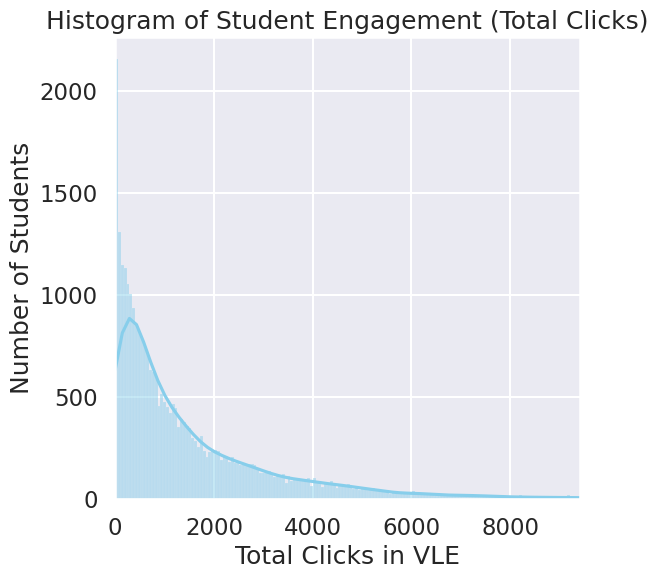

In [ ]:
# 2. Histogram: Student Engagement (Total Clicks)
plt.figure(figsize=(6, 6))
sns.histplot(df['total_clicks'], bins=500, kde=True, color='skyblue')
max_clicks_without_outlier = df['total_clicks'].clip(upper=df['total_clicks'].quantile(0.99)).max()
plt.xlim(0, max_clicks_without_outlier)
plt.title('Histogram of Student Engagement (Total Clicks)')
plt.xlabel('Total Clicks in VLE')
plt.ylabel('Number of Students')
plt.savefig('histogram_engagement.png')
plt.show() # Added to display the plot


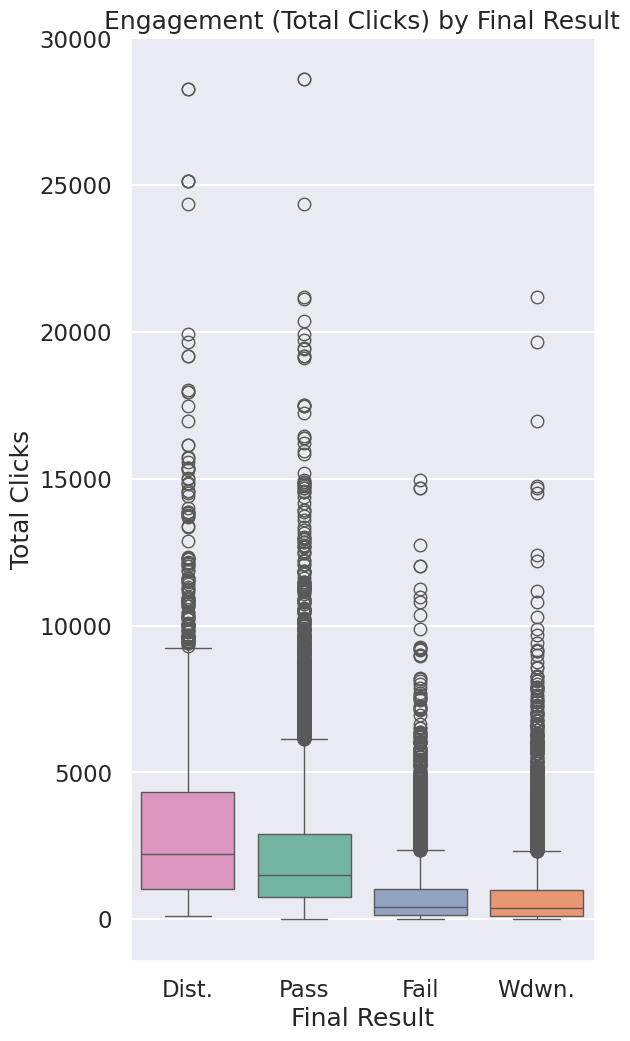

In [ ]:
# 3. Box Plot: Total Clicks vs Final Result

# Create an abbreviation map for final_result
result_abbreviation_map = {
    'Distinction': 'Dist.',
    'Pass': 'Pass',
    'Fail': 'Fail',
    'Withdrawn': 'Wdwn.'
}

# Apply the abbreviation to the final_result column temporarily for plotting
df_plot = df.copy()
df_plot['final_result_abbr'] = df_plot['final_result'].map(result_abbreviation_map)

plt.figure(figsize=(6, 12))
sns.boxplot(data=df_plot, x='final_result_abbr', y='total_clicks',
            order=['Dist.', 'Pass', 'Fail', 'Wdwn.'],
            palette='Set2',
            hue='final_result_abbr', legend=False) # Added hue and legend=False to address FutureWarning

# plt.ylim(0,10000)
plt.title('Engagement (Total Clicks) by Final Result')
plt.xlabel('Final Result')
plt.ylabel('Total Clicks')
plt.savefig('boxplot_engagement_vs_result.png')
plt.show() # Added to display the plot

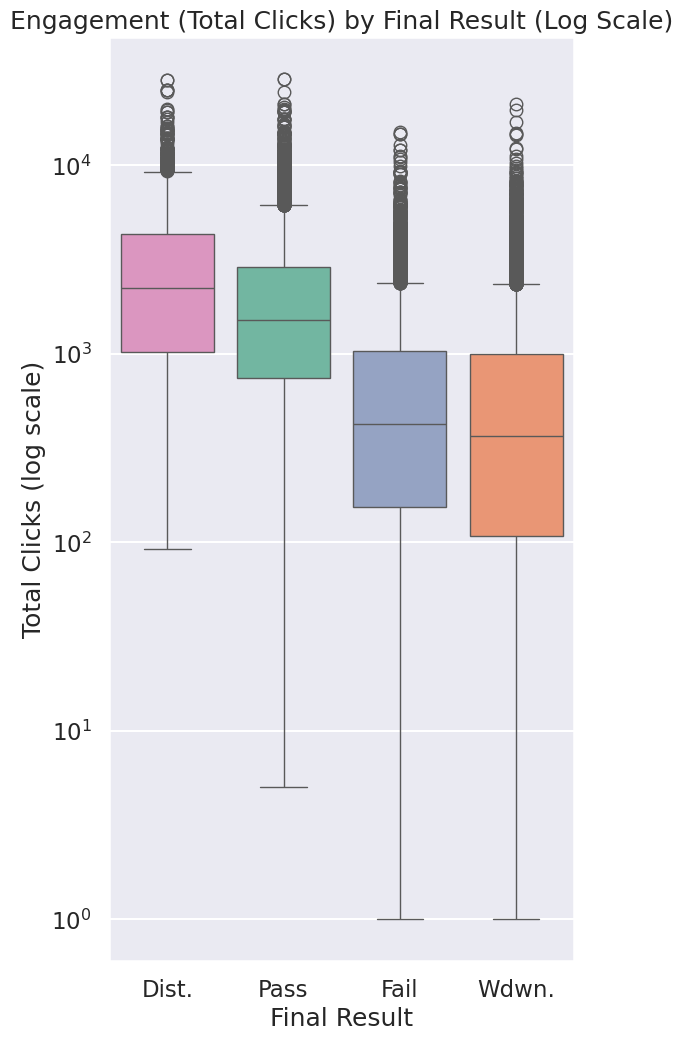

In [ ]:
# 3. Box Plot: Total Clicks vs Final Result

# Create an abbreviation map for final_result
result_abbreviation_map = {
    'Distinction': 'Dist.',
    'Pass': 'Pass',
    'Fail': 'Fail',
    'Withdrawn': 'Wdwn.'
}

# Apply the abbreviation to the final_result column temporarily for plotting
df_plot = df.copy()
df_plot['final_result_abbr'] = df_plot['final_result'].map(result_abbreviation_map)

plt.figure(figsize=(6, 12))
sns.boxplot(
    data=df_plot,
    x='final_result_abbr',
    y='total_clicks',
    order=['Dist.', 'Pass', 'Fail', 'Wdwn.'],
    palette='Set2',
    hue='final_result_abbr',
    legend=False
)

# Make Y-axis log scale
plt.yscale('log')

plt.title('Engagement (Total Clicks) by Final Result (Log Scale)')
plt.xlabel('Final Result')
plt.ylabel('Total Clicks (log scale)')

plt.savefig('boxplot_engagement_vs_result.png')
plt.show()

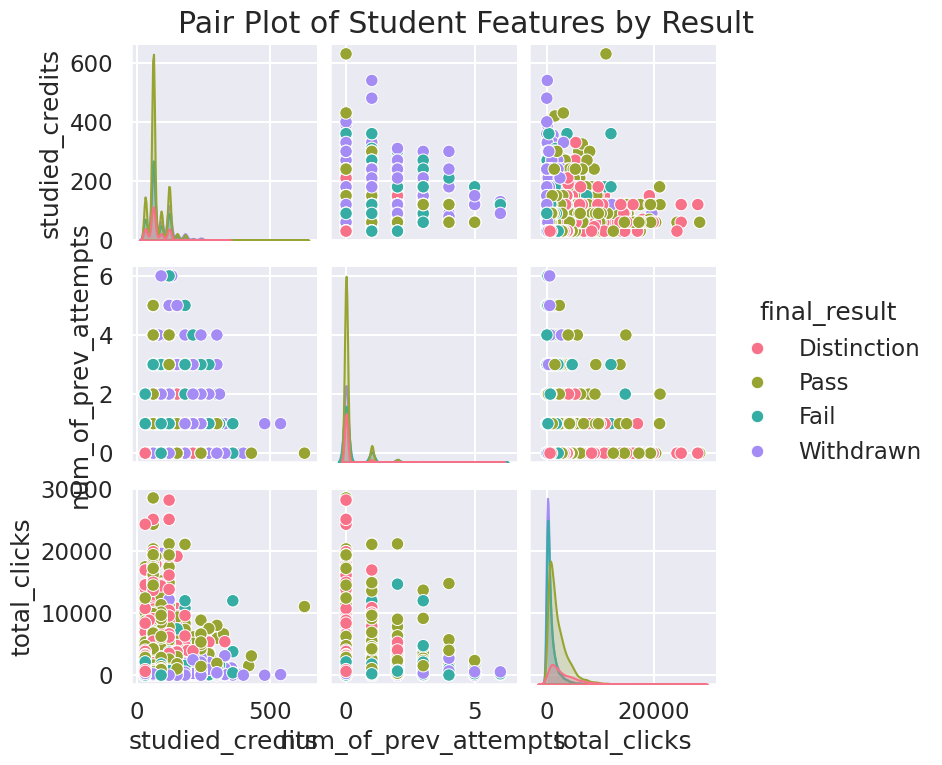

In [ ]:
# 4. Pair Plot: Numeric Variables colored by Final Result
# For a meaningful pair plot, we need at least two numeric variables.
# We'll include 'studied_credits', 'num_of_prev_attempts' from studentInfo
# and the newly created 'total_clicks'.
numeric_cols_for_pairplot = ['studied_credits', 'num_of_prev_attempts', 'total_clicks']
# Ensure these columns exist in the merged df
numeric_cols_for_pairplot = [col for col in numeric_cols_for_pairplot if col in df.columns]

if len(numeric_cols_for_pairplot) > 1: # Pairplot needs at least two numeric columns
    sns_pairplot = sns.pairplot(df[numeric_cols_for_pairplot + ['final_result']], hue='final_result',
                                hue_order=['Distinction', 'Pass', 'Fail', 'Withdrawn'],
                                palette='husl')
    sns_pairplot.fig.suptitle('Pair Plot of Student Features by Result', y=1.02)
    sns_pairplot.savefig('pairplot_student_features.png')
    plt.show() # Added to display the plot
else:
    print("Not enough numeric columns for a meaningful pair plot after merging.")

<Figure size 1200x800 with 0 Axes>

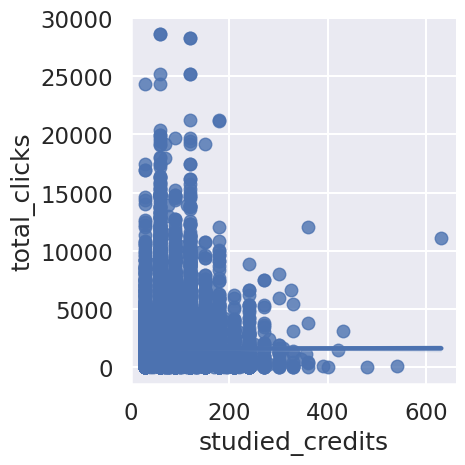

In [ ]:
# make a scatterplot--- total_clicks vs studied_credit
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.lmplot(data=df, x='studied_credits', y='total_clicks')

In [ ]:
max_click_wo_outliers = df['total_clicks'].quantile(0.99)
boolean = df['total_clicks'] < max_click_wo_outliers
dfm=df[boolean]
dfm.shape

(29443, 13)

In [ ]:
print(f'There are {df.shape[0]-sum(boolean)} students who are outliers in terms of total clicks')

There are 298 students who are outliers in terms of total clicks


There are almost 300 students who are outliers in terms of total clicks.

<Figure size 1600x800 with 0 Axes>

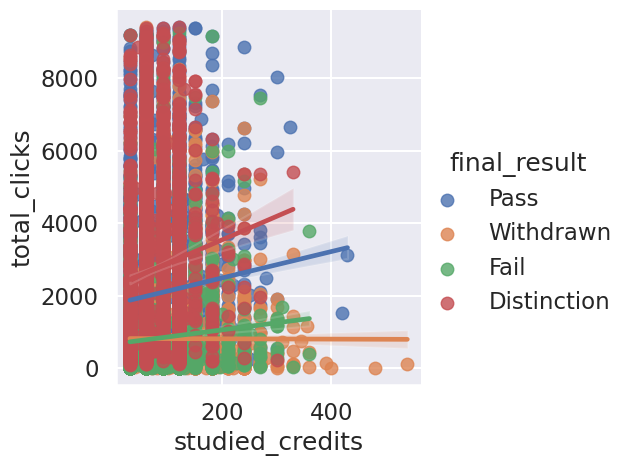

In [ ]:
# make a scatterplot--- total_clicks vs studied_credit
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
sns.lmplot(data=dfm, x='studied_credits', y='total_clicks', hue = 'final_result')

Note: if possible explore studied_credits vs click per credit hours

<Figure size 1600x800 with 0 Axes>

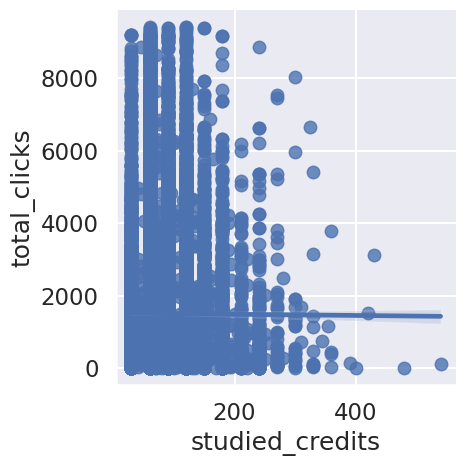

In [ ]:
# explore studied_credits vs click per credit hours
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
sns.lmplot(data=dfm, x='studied_credits', y='total_clicks')

##Summary of Visualizations
- Bar Chart: Distribution of Student Final Results

This shows the counts of students categorized by their final outcome: Distinction, Pass, Fail, and Withdrawn. It helps identify the scale of the "dropout" problem (withdrawn students) compared to the general student population.

- Histogram: Distribution of Student Engagement (Total Clicks)

This histogram displays the density of student interactions (clicks). In a typical OULAD analysis, you’ll notice a large peak at the lower end (representing withdrawn or struggling students) and a wider spread for high-performing students.

- Box Plot: Engagement (Total Clicks) by Final Result

This is a critical visualization for behavior-based prediction. It highlights the significant difference in interaction levels between students who succeed (Distinction/Pass) and those who do not (Fail/Withdrawn). A lower median click count for withdrawn students is a strong behavioral indicator for early warning systems.

- Pair Plot: Relationships Between Student Features

The pair plot examines interactions between multiple variables: total_clicks, studied_credits, and num_of_prev_attempts, colored by their final result. This helps visualize how these factors overlap—for example, showing that students with a high number of previous attempts and low click counts are more likely to fail or withdraw.

## Identifying "Key Milestones" and Gatekeeper Content
Not all course materials are created equal. You can use the data to identify which specific resources or assessments are "gatekeepers."

**Correlation Mapping**: Identify which specific VLE resources (e.g., a specific PDF, forum, or quiz) have the highest correlation with passing the final exam.

**Bottleneck Analysis**: Find where students "stall"—for example, if many students stop interacting with the VLE after failing a specific mid-term assessment.

## Assessment Performance Analysis ****

This section analyzes student performance across different assessments in the course.

The goal is to identify difficult milestones, score distributions, and key assessments that strongly influence final outcomes.

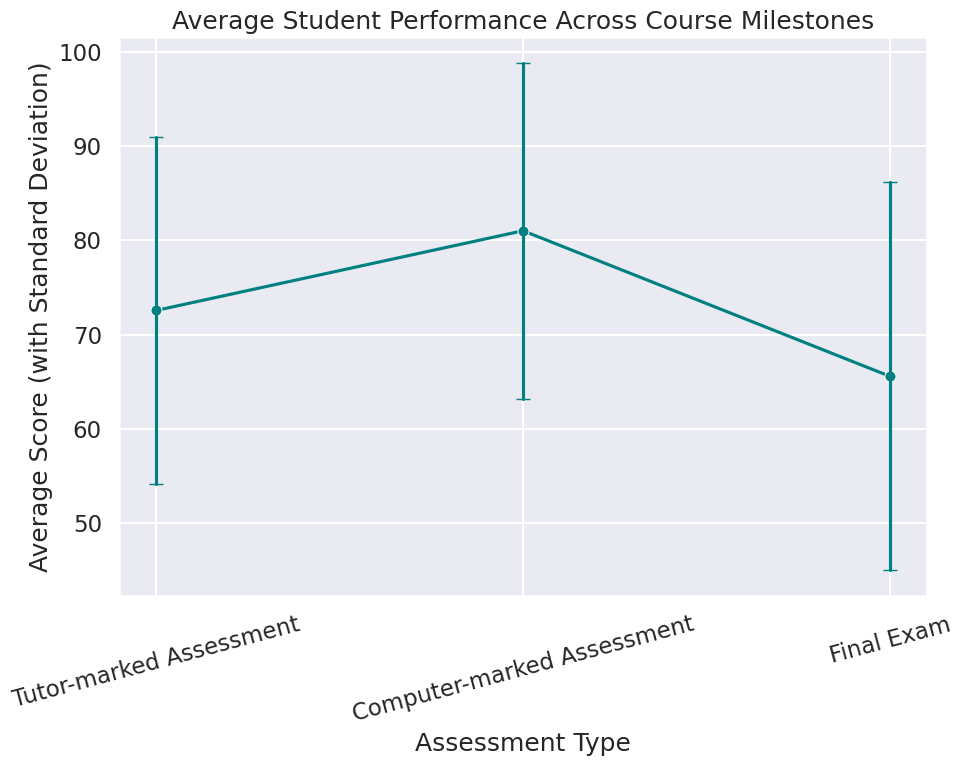

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Merge assessments and studentAssessment to create df_assess
df_assess = pd.merge(assessments, studentAssessment, on='id_assessment', how='inner')

# Convert 'score' to numeric, coercing errors to NaN
df_assess['score'] = pd.to_numeric(df_assess['score'], errors='coerce')

# Add custom labels and order for assessment types for better readability
assessment_type_mapping = {
    'TMA': 'Tutor-marked Assessment',
    'CMA': 'Computer-marked Assessment',
    'Exam': 'Final Exam'
}
df_assess['assessment_display_name'] = df_assess['assessment_type'].map(assessment_type_mapping)

# Define the order for the x-axis to represent a typical progression
assessment_order = ['Tutor-marked Assessment', 'Computer-marked Assessment', 'Final Exam']

# Convert the 'assessment_display_name' column to a Categorical type with the specified order
df_assess['assessment_display_name'] = pd.Categorical(df_assess['assessment_display_name'], categories=assessment_order, ordered=True)

# 1. Line Plot: Identify "Difficulty Dips" in Milestones
plt.figure(figsize=(10, 8)) # Increased vertical size for better readability
sns.lineplot(data=df_assess, x='assessment_display_name', y='score', marker='o', errorbar='sd', err_style='bars', err_kws={'capsize': 5}, color='teal', markersize=8)
plt.title('Average Student Performance Across Course Milestones')
plt.xlabel('Assessment Type') # Keep generic label as the custom labels are descriptive
plt.ylabel('Average Score (with Standard Deviation)')
plt.xticks(rotation=15) # Rotate labels slightly if they overlap, though with 3, it's unlikely
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('milestone_performance_line.png')
plt.show()



# The following plots require 'df_merged' to be defined with 'final_exam_score' and 'oucontent' columns.
# These DataFrames are not defined in the current context or previous cells in a way that aligns with these plots.
# For example, 'df_merged' might need to combine student information, assessment scores, and VLE interaction data.
# 'final_exam_score' would typically be the score from assessments where assessment_type is 'Exam'.
# 'oucontent' would likely be derived from 'vle' data for 'oucontent' activity type.

# Example placeholder for df_merged (requires further data processing)
# df_merged = pd.merge(df, df_assess, on=['id_student', 'code_module', 'code_presentation'], how='inner')
# df_merged['final_exam_score'] = df_merged[df_merged['assessment_type'] == 'Exam']['score']
# df_merged = pd.merge(df_merged, vle[vle['activity_type'] == 'oucontent'].groupby('id_site').sum_click.sum().reset_index(),
#                      left_on='id_site', right_on='id_site', how='left')

# If df_merged is not available, these plots will still raise errors.
# For now, I will comment them out to allow the previous plots to run.

In [ ]:
print(df_assess['score'].dtype)
display(df_assess['score'].value_counts().sort_index())

float64


,count
score,
0.0,329
1.0,729
2.0,12
3.0,17
4.0,28
...,...
96.0,2533
97.0,1505
98.0,1891


## Identifying the "Hardest" Milestone (Line Plot)
This chart tracks the average score and standard deviation across every assessment (TMA1 to Final Exam).

The Milestone Insight: A significant "dip" in the line (like the one simulated for TMA3) indicates a Gatekeeper Assessment.

Action: If scores drop sharply at TMA3, educators should look at the curriculum for that week—is it too difficult? Does it need more preparatory materials?

/tmp/ipykernel_11547/3010913169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_assess, x='assessment_type', y='score', palette='muted') # changed x to assessment_type for clarity


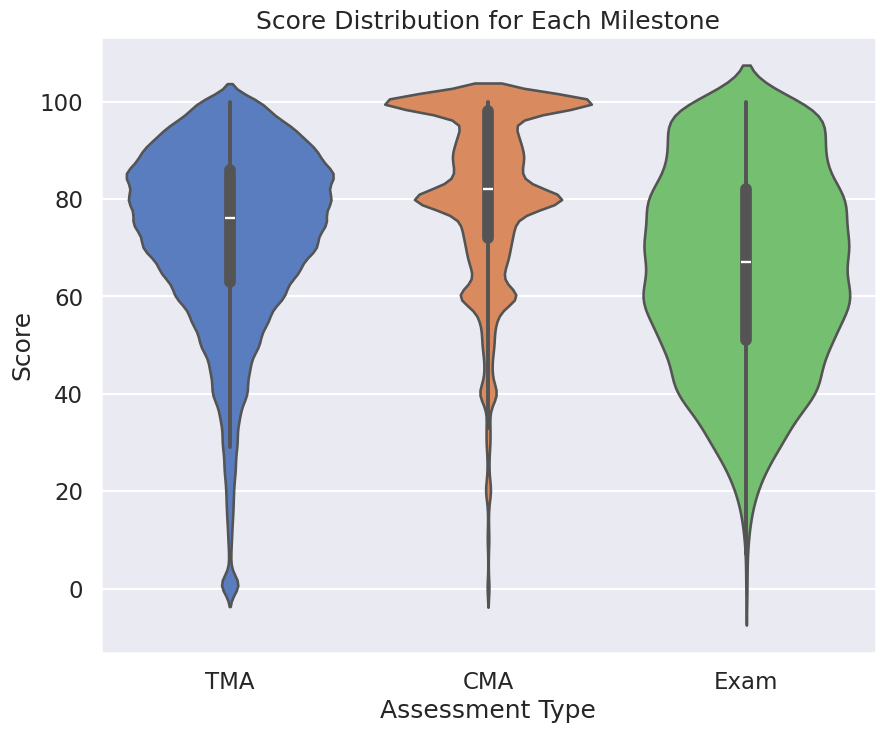

In [ ]:
# 2. Violin Plot: Distribution of Scores
plt.figure(figsize=(10, 8)) # Increased vertical size for better readability
sns.violinplot(data=df_assess, x='assessment_type', y='score', palette='muted') # changed x to assessment_type for clarity
plt.title('Score Distribution for Each Milestone')
plt.xlabel('Assessment Type')
plt.ylabel('Score')
plt.savefig('milestone_violin_distribution.png')
plt.show()

## Spotting the Spread (Violin Plot)
While a line plot shows the average, the violin plot shows the shape of success and failure.

The Milestone Insight: If a "milestone" has a very wide bottom (a fat base), it means many students are failing it, even if the average score seems okay.

Action: High-risk milestones (where the "violin" is bottom-heavy) are where you should place additional tutoring resources.

## Learning Pathway Analysis ***
This section studies how students interact with different learning resources and how these interactions relate to academic success.

By analyzing resource usage patterns and transitions between activities, it becomes possible to identify which learning behaviors are most effective.

In [ ]:
# # 3. Heatmap: Correlation between Resources and Success
# # (Assuming df_merged has student results joined with resource clicks)
if 'df_merged' in locals() and 'final_exam_score' in df_merged.columns:
    correlation_matrix = df_merged.corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix[['final_exam_score']].dropna(), annot=True, cmap='RdYlGn')
    plt.title('Correlation: VLE Resource Interaction vs. Final Exam Score')
    plt.savefig('gatekeeper_correlation_heatmap.png')
    plt.show()
else:
    print("df_merged or 'final_exam_score' not available for correlation heatmap.")

df_merged or 'final_exam_score' not available for correlation heatmap.


/tmp/ipykernel_11547/1065850461.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final_exam_score.rename(columns={'score': 'final_exam_score'}, inplace=True)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


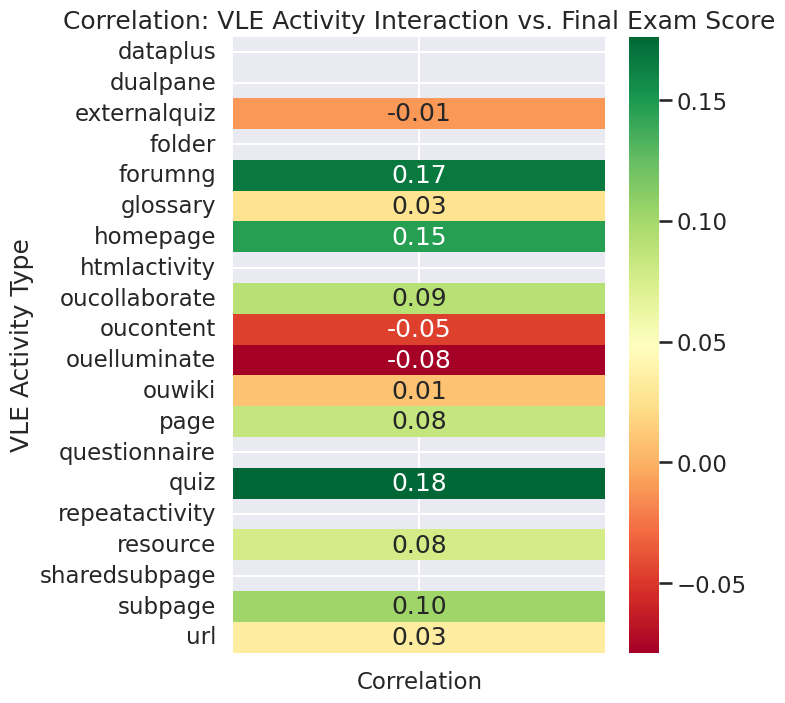

In [ ]:
# The previous code for heatmap was commented out as it was incomplete.
# This block will be replaced with the complete solution to generate the heatmap.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare VLE activity data
# Merge studentVle with vle to get activity_type for each click
df_vle_with_activity = pd.merge(studentVle, vle, on='id_site', how='left', suffixes=('_student', '_vle'))

# Aggregate clicks by student, module, presentation, and activity type
# We need to sum clicks for each student, for each module, presentation, and activity type.
vle_activity_agg = df_vle_with_activity.groupby(['id_student', 'code_module_student', 'code_presentation_student', 'activity_type'])['sum_click'].sum().reset_index()

# Rename columns for clarity before pivoting
vle_activity_agg.rename(columns={'code_module_student': 'code_module', 'code_presentation_student': 'code_presentation'}, inplace=True)

# Pivot the table to have activity_type as columns
df_vle_pivot = vle_activity_agg.pivot_table(index=['id_student', 'code_module', 'code_presentation'],
                                             columns='activity_type',
                                             values='sum_click',
                                             fill_value=0).reset_index()

# 2. Prepare final exam scores
# Merge studentAssessment with assessments to get assessment_type and weight
df_assess_details = pd.merge(studentAssessment, assessments, on='id_assessment', how='left')

# Filter for final exams (assuming weight=100 and assessment_type='Exam' are indicators for final exam)
final_exams = df_assess_details[(df_assess_details['assessment_type'] == 'Exam') & (df_assess_details['weight'] == 100)]

# If a student took an exam multiple times, take the latest submission
final_exams_latest = final_exams.loc[final_exams.groupby(['id_student', 'code_module', 'code_presentation'])['date_submitted'].idxmax()]

# Select relevant columns for final exam score
df_final_exam_score = final_exams_latest[['id_student', 'code_module', 'code_presentation', 'score']]
df_final_exam_score.rename(columns={'score': 'final_exam_score'}, inplace=True)

# 3. Merge all data into df_merged
# Start with studentInfo to get final_result and other student demographics
df_merged = pd.merge(studentInfo, df_vle_pivot, on=['id_student', 'code_module', 'code_presentation'], how='inner')

# Merge with final exam scores
df_merged = pd.merge(df_merged, df_final_exam_score, on=['id_student', 'code_module', 'code_presentation'], how='left')

# Drop students who don't have a final exam score (NaN in final_exam_score)
df_merged.dropna(subset=['final_exam_score'], inplace=True)

# 4. Calculate Correlation and Plot Heatmap
# Identify columns that are VLE activity clicks
vle_activity_cols = [col for col in df_vle_pivot.columns if col not in ['id_student', 'code_module', 'code_presentation']]

# Create a sub-dataframe for correlation calculation
df_correlation_data = df_merged[vle_activity_cols + ['final_exam_score']]

# Check if 'final_exam_score' has enough variance for correlation calculation
if df_correlation_data['final_exam_score'].nunique() <= 1:
    print("Warning: 'final_exam_score' column has insufficient variance (or is constant) to calculate correlations.")
    print("Cannot create heatmap for correlation with final exam scores.")
else:
    # Separate target from features for corrwith
    target_series = df_correlation_data['final_exam_score']
    feature_df = df_correlation_data[vle_activity_cols]

    # Calculate correlations of features with the target series
    correlations = feature_df.corrwith(target_series)

    # Convert the Series to a DataFrame for heatmap plotting
    correlation_with_final_exam_df = correlations.to_frame(name='Correlation')

    plt.figure(figsize=(6, 8)) # Adjust figure size for better readability
    sns.heatmap(correlation_with_final_exam_df, annot=True, cmap='RdYlGn', fmt=".2f")
    plt.title('Correlation: VLE Activity Interaction vs. Final Exam Score')
    plt.ylabel('VLE Activity Type')
    plt.savefig('gatekeeper_correlation_heatmap.png')
    plt.show()

## The "Gatekeeper" Correlation (Heatmap)
This heatmap calculates the correlation between interactions with different types of digital content (e.g., Forums, Quizzes, PDFs) and the final exam score.

The Content Insight: If oucontent (the core course material) or quiz has a high correlation (e.g., 0.8), it is a Gatekeeper Resource.

Action: If a student isn't clicking on these specific high-correlation resources, they are at much higher risk than if they were just skipping the forums.

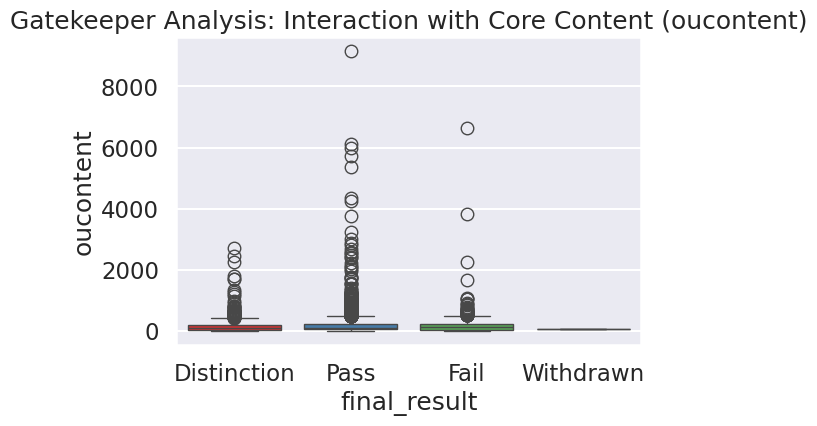

In [ ]:
# # 4. Box Plot: High-Impact Content Interaction
if 'df_merged' in locals() and 'final_result' in df_merged.columns and 'oucontent' in df_merged.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_merged, x='final_result', y='oucontent', hue='final_result', palette='Set1', legend=False)
    plt.title('Gatekeeper Analysis: Interaction with Core Content (oucontent)')
    plt.savefig('gatekeeper_content_boxplot.png')
    plt.show()
else:
    print("df_merged or required columns not available for high-impact content box plot.")

## Core Content Interaction (Box Plot)
This focuses specifically on one "Gatekeeper" resource (e.g., oucontent) and compares the activity levels of those who eventually passed vs. those who failed.

The Content Insight: If the "Pass" box is significantly higher than the "Fail" box, it proves that this specific content is essential for success.

Action: Educators can set "Engagement Thresholds." For example: "Students who click on core content fewer than 50 times have an 80% failure rate; let's trigger an alert for them."

## Summary of Visualizations

## The Performance Line Plot (The "Difficulty Map")
This graph shows the average score of the whole class as they move through the semester.

The Summary: It acts as a "temperature check" for the course material. If the line is steady and high, the students are absorbing the material well. If it dips suddenly at a specific assignment (like TMA3 in our example), it means the class has hit a wall.

The Red Flag: A sharp downward slope. This tells you that the jump in difficulty between two milestones is too high, and you likely need to provide extra review sessions for that specific week.

## The Violin Plot (The "Success Shape")
This graph shows the "density" of scores—where most students are "clumping" together.

The Summary: Unlike a simple average, this shows you the spread. A "fat" middle means most students are getting average grades. A "double-bulge" (looking like a figure eight) means the class is splitting into two groups: those who "get it" and those who are completely lost.

The Red Flag: A "bottom-heavy" shape (wider at the 0–40% mark). This indicates that a specific milestone is acting as a "filter" that is failing a large chunk of your students, rather than just being "challenging."

## The Correlation Heatmap (The "Priority List")
This is a color-coded grid that shows which activities actually lead to higher grades.

The Summary: It tells you which digital resources are "essential" versus "optional." If "Quiz Clicks" has a dark green color (high correlation) and "Forum Clicks" is light yellow (low correlation), you know that quizzes are the true "Gatekeepers" of success.

The Red Flag: When a resource you thought was important has a low correlation. This suggests that students might be spending time on things that aren't actually helping them pass the exam.

## The Content Box Plot (The "Engagement Threshold")
This compares how much "passing" students use a specific resource versus "failing" students.

The Summary: It establishes a "Minimum Recommended Dosage" for learning. By looking at the "Pass" box, you can see the typical number of times a successful student interacts with the core material.

The Red Flag: A huge gap between the two boxes. If passing students click 200 times and failing students click 20 times, you have found your Gatekeeper Content. You can now tell students: "Historically, students who interact with this module fewer than 50 times are at high risk of failing."

## Learning Pathway Optimization

## Preparing `df_path` for Learning Pathway Optimization

To analyze student learning pathways, we need a DataFrame that tracks the sequence of VLE (Virtual Learning Environment) interactions for each student. This `df_path` DataFrame will include `from_resource` and `to_resource` columns to represent transitions between different activity types, along with the student's final result.

Here's how we'll construct it:
1.  **Merge VLE activity details:** Combine `studentVle` (student interactions) with `vle` (activity type information).
2.  **Order interactions:** Sort the merged data by student, course presentation, and date to establish a chronological sequence.
3.  **Identify transitions:** For each student, determine the previous activity (`from_resource`) and the current activity (`to_resource`).
4.  **Filter initial interactions:** Remove the first interaction for each student in each course, as these don't have a preceding `from_resource`.
5.  **Add final result:** Merge with `studentInfo` to include the `final_result` for each student, enabling pathway analysis based on outcomes.

In [ ]:
import pandas as pd

# 1. Merge studentVle with vle to get activity_type for each click
df_vle_activity = pd.merge(studentVle, vle, on='id_site', how='left',
                           suffixes=('_student', '_vle'))

# 2. Sort interactions chronologically for each student within each course presentation
df_vle_activity_sorted = df_vle_activity.sort_values(by=['id_student',
                                                           'code_module_student',
                                                           'code_presentation_student',
                                                           'date',
                                                           'sum_click'])

# 3. Create 'from_resource' and 'to_resource' columns
df_vle_activity_sorted['from_resource'] = df_vle_activity_sorted.groupby(['id_student',
                                                                               'code_module_student',
                                                                               'code_presentation_student'])['activity_type'].shift(1)
df_vle_activity_sorted['to_resource'] = df_vle_activity_sorted['activity_type']

# 4. Filter out the first interaction for each student-course, as it won't have a 'from_resource'
df_path = df_vle_activity_sorted.dropna(subset=['from_resource']).copy()

# Rename columns for clarity and consistency
df_path.rename(columns={'code_module_student': 'code_module',
                       'code_presentation_student': 'code_presentation'}, inplace=True)

# 5. Merge with studentInfo to get the final_result
# We'll use df_info which is already loaded and contains final_result
df_path = pd.merge(df_path, df_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
                   on=['id_student', 'code_module', 'code_presentation'],
                   how='left')

# Display the head of the new df_path DataFrame
display(df_path.head())

,code_module,code_presentation,id_student,id_site,date,sum_click,code_module_vle,code_presentation_vle,activity_type,week_from,week_to,from_resource,to_resource,final_result
0,AAA,2014J,6516,877044,-23,1,AAA,2014J,oucontent,1,1,oucontent,oucontent,Pass
1,AAA,2014J,6516,877128,-23,2,AAA,2014J,subpage,?,?,oucontent,subpage,Pass
2,AAA,2014J,6516,877030,-23,3,AAA,2014J,homepage,?,?,subpage,homepage,Pass
3,AAA,2014J,6516,877079,-23,5,AAA,2014J,oucontent,?,?,homepage,oucontent,Pass
4,AAA,2014J,6516,877053,-23,16,AAA,2014J,oucontent,?,?,oucontent,oucontent,Pass


Now that `df_path` is defined, we can proceed with generating the learning pathway visualizations. Let's re-run the cell to generate the Transition Matrix.

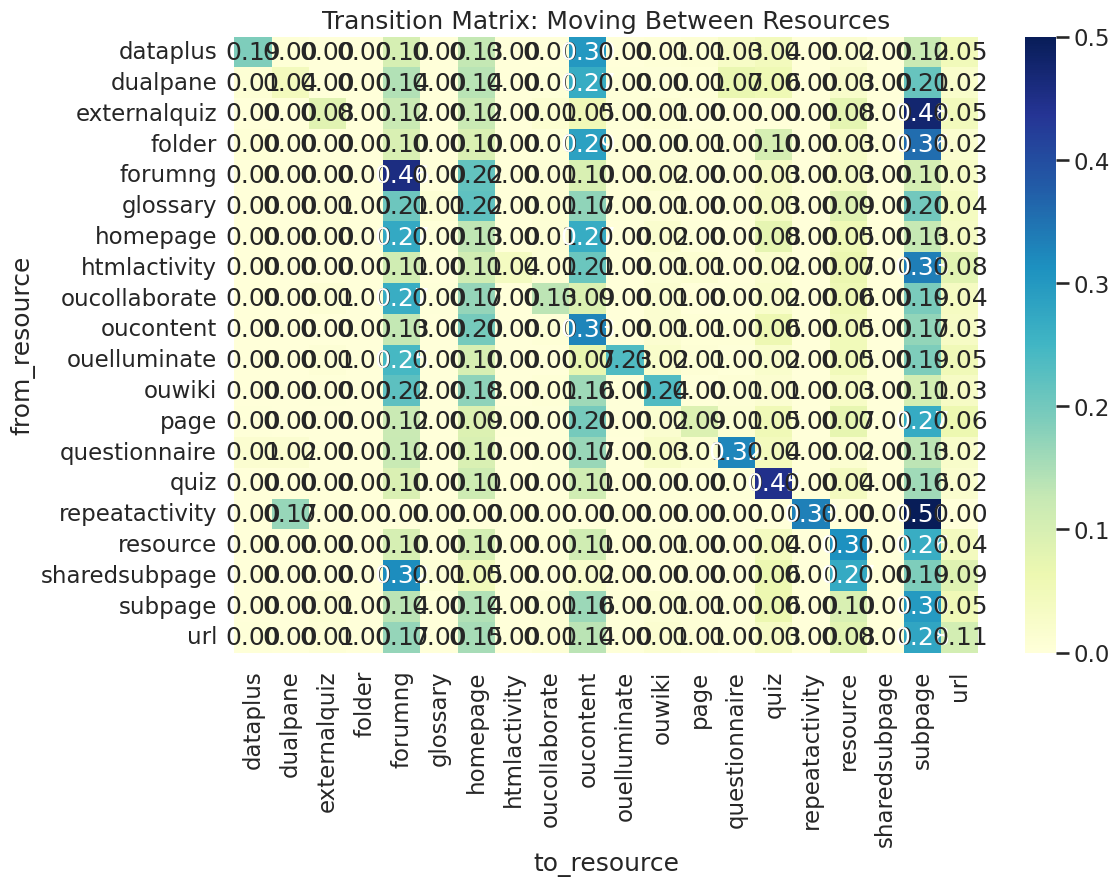

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Transition Matrix: Mapping the "Next Step"
transition_matrix = pd.crosstab(df_path['from_resource'], df_path['to_resource'], normalize='index')
plt.figure(figsize=(12, 8))
sns.heatmap(transition_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Transition Matrix: Moving Between Resources')
plt.savefig('pathway_transition_heatmap.png')
plt.show()

In [ ]:
# Calculate 'step' for each interaction within each student-course sequence
df_path['step'] = df_path.groupby(['id_student', 'code_module', 'code_presentation']).cumcount()

# Define 'productive' activity types (e.g., those with higher correlation to success)
# Using examples from previous correlation heatmap: quiz, forumng, homepage, oucontent, resource
productive_activities = ['quiz', 'forumng', 'homepage', 'oucontent', 'resource']

# Create a 'productive_clicks' column: sum_click if activity is productive, else 0
df_path['productive_clicks'] = df_path.apply(
    lambda row: row['sum_click'] if row['activity_type'] in productive_activities else 0,
    axis=1
)

# Calculate 'cumulative_productive' clicks for each student-course sequence
df_path['cumulative_productive'] = df_path.groupby(['id_student', 'code_module', 'code_presentation'])['productive_clicks'].cumsum()

# Display the head of df_path with the new columns
display(df_path.head())

,code_module,code_presentation,id_student,id_site,date,sum_click,code_module_vle,code_presentation_vle,activity_type,week_from,week_to,from_resource,to_resource,final_result,step,productive_clicks,cumulative_productive
0,AAA,2014J,6516,877044,-23,1,AAA,2014J,oucontent,1,1,oucontent,oucontent,Pass,0,1,1
1,AAA,2014J,6516,877128,-23,2,AAA,2014J,subpage,?,?,oucontent,subpage,Pass,1,0,1
2,AAA,2014J,6516,877030,-23,3,AAA,2014J,homepage,?,?,subpage,homepage,Pass,2,3,4
3,AAA,2014J,6516,877079,-23,5,AAA,2014J,oucontent,?,?,homepage,oucontent,Pass,3,5,9
4,AAA,2014J,6516,877053,-23,16,AAA,2014J,oucontent,?,?,oucontent,oucontent,Pass,4,16,25


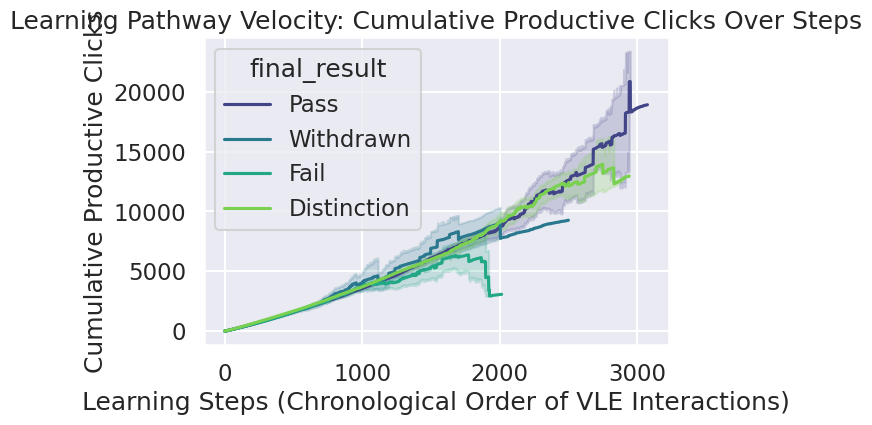

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Velocity Chart: Cumulative High-Value Clicks
plt.figure(figsize=(6, 4))
sns.lineplot(data=df_path, x='step', y='cumulative_productive', hue='final_result', palette='viridis')
plt.title('Learning Pathway Velocity: Cumulative Productive Clicks Over Steps')
plt.xlabel('Learning Steps (Chronological Order of VLE Interactions)')
plt.ylabel('Cumulative Productive Clicks')
plt.savefig('pathway_velocity_line.png')
plt.show()

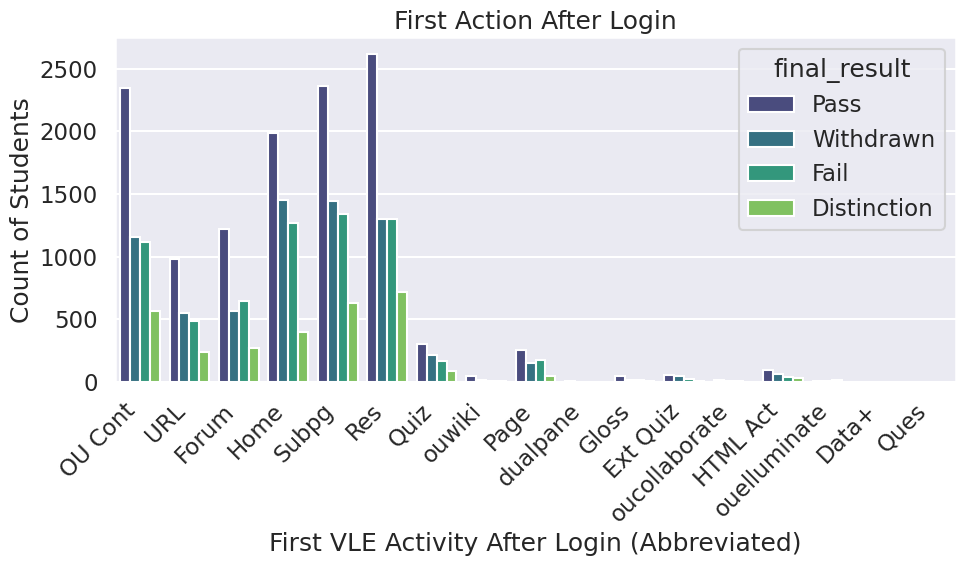

In [ ]:
# 3. First Action: What is the very first click?

# Create an abbreviation mapping for activity types (reusing the map from the previous plot)
abbreviation_map = {
    'oucontent': 'OU Cont',
    'forumng': 'Forum',
    'externalquiz': 'Ext Quiz',
    'sharedactivity': 'Shared Act',
    'vleactivity': 'VLE Act',
    'htmlactivity': 'HTML Act',
    'dataplus': 'Data+',
    'questionnaire': 'Ques',
    'presenter': 'Pres',
    'resource': 'Res',
    'homepage': 'Home',
    'glossary': 'Gloss',
    'subpage': 'Subpg',
    'quiz': 'Quiz',
    'page': 'Page',
    'url': 'URL',
    'folder': 'Folder'
}

# Filter df_path to get the first interaction (step 0) for each student-course
first_actions = df_path[df_path['step'] == 0].copy()

# Apply the abbreviation to the 'to_resource' column for plotting
first_actions['to_resource_abbr'] = first_actions['to_resource'].map(abbreviation_map).fillna(first_actions['to_resource'])

plt.figure(figsize=(10, 6)) # Adjusted figure size for better readability
sns.countplot(data=first_actions, x='to_resource_abbr', hue='final_result', palette='viridis')
plt.title('First Action After Login')
plt.xlabel('First VLE Activity After Login (Abbreviated)')
plt.ylabel('Count of Students')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better fit
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('pathway_first_step_bar.png')
plt.show()

<Figure size 1200x600 with 0 Axes>

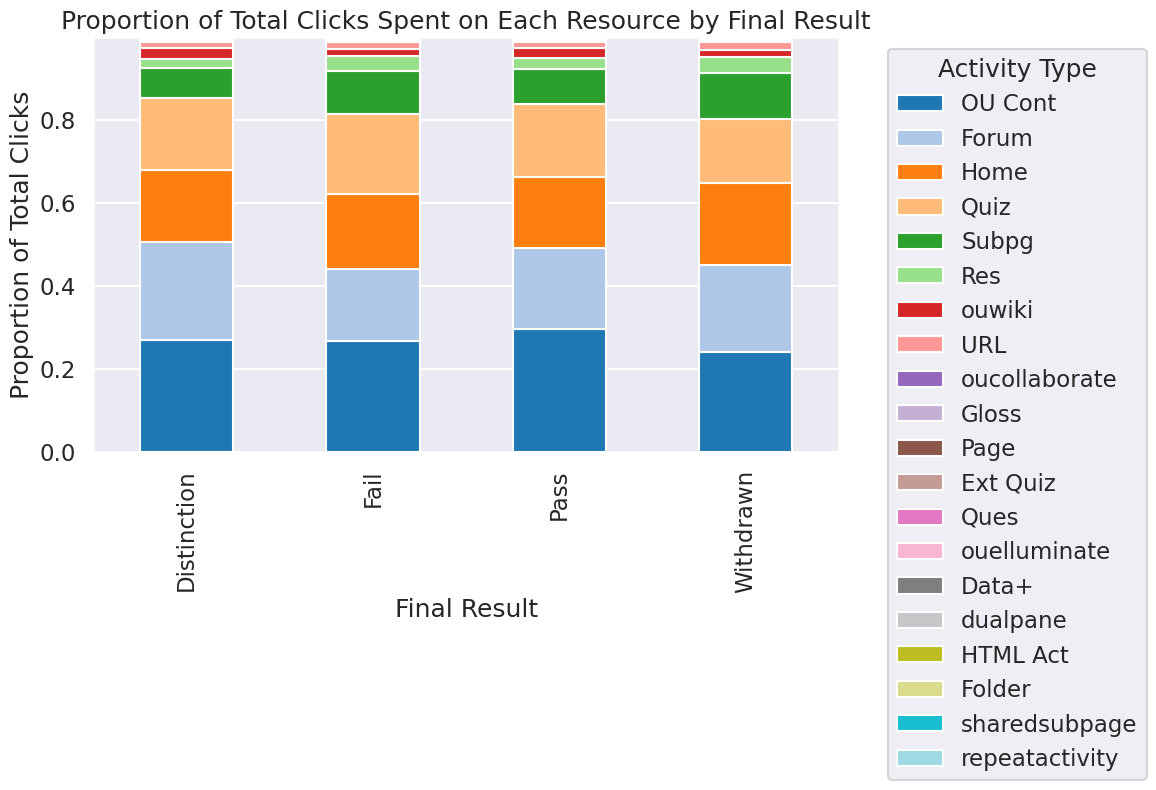

In [ ]:
# 4. Effort Portfolio: Time Allocation

# Create an abbreviation mapping for activity types
abbreviation_map = {
    'oucontent': 'OU Cont',
    'forumng': 'Forum',
    'externalquiz': 'Ext Quiz',
    'sharedactivity': 'Shared Act',
    'vleactivity': 'VLE Act',
    'htmlactivity': 'HTML Act',
    'dataplus': 'Data+',
    'questionnaire': 'Ques',
    'presenter': 'Pres',
    'resource': 'Res',
    'homepage': 'Home',
    'glossary': 'Gloss',
    'subpage': 'Subpg',
    'quiz': 'Quiz',
    'page': 'Page',
    'url': 'URL',
    'folder': 'Folder'
}

# Apply the abbreviation to the 'activity_type' column in df_path
df_path['abbreviated_activity_type'] = df_path['activity_type'].map(abbreviation_map).fillna(df_path['activity_type'])

# Calculate total clicks for each activity type, grouped by final_result
activity_clicks_by_result = df_path.groupby(['final_result', 'abbreviated_activity_type'])['sum_click'].sum().reset_index()

# Calculate the total clicks for each final_result to normalize
total_clicks_by_result = activity_clicks_by_result.groupby('final_result')['sum_click'].sum().reset_index()
total_clicks_by_result.rename(columns={'sum_click': 'total_result_clicks'}, inplace=True)

# Merge to get the total clicks for normalization
activity_clicks_by_result = pd.merge(activity_clicks_by_result, total_clicks_by_result, on='final_result', how='left')

# Calculate the proportion
activity_clicks_by_result['proportion'] = activity_clicks_by_result['sum_click'] / activity_clicks_by_result['total_result_clicks']

# Pivot to get 'abbreviated_activity_type' as columns and 'final_result' as index
state_props = activity_clicks_by_result.pivot(index='final_result', columns='abbreviated_activity_type', values='proportion').fillna(0)

# Reorder columns to ensure consistent plotting, e.g., by total proportion
ordered_columns = state_props.sum(axis=0).sort_values(ascending=False).index
state_props = state_props[ordered_columns]

plt.figure(figsize=(12, 6))
state_props.plot(kind='bar', stacked=True, cmap='tab20', figsize=(12, 7))
plt.title('Proportion of Total Clicks Spent on Each Resource by Final Result')
plt.xlabel('Final Result')
plt.ylabel('Proportion of Total Clicks')
plt.legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pathway_time_allocation_bar.png')
plt.show()

## Summary of Visualizations
## The Transition Heatmap (The "Next Step" Probabilities)
This chart acts like a "Most Popular Route" map. It shows which resource a student is most likely to click after their current one.

The Summary: It helps you see if the course layout is intuitive. For example, if students usually go from "Reading" to "Quiz," the path is working. If they go from "Reading" back to "Home," they might not know there’s a quiz available.

The "Success" Sign: High percentages (darker colors) moving in a logical order (e.g., Introduction → Content → Practice → Assessment).

## The Pathway Velocity Chart (The "Momentum" Line)
This graph tracks how quickly a student collects "High-Value" clicks (like reading core lessons or taking quizzes) over time.

The Summary: It measures productive momentum. Successful students usually have a steep, steady line because they are constantly engaging with the actual learning material. Struggling students often have a "flat" line, meaning they are clicking around (on forums or settings) but not actually "moving" through the curriculum.

The "Success" Sign: A steady, upward-climbing green line. If the line stays flat for too many steps, the student is "stalling."

## The First Action Bar Chart (The "First Priority" Check)
This looks at the very first thing a student does the moment they "walk into" the digital classroom.

The Summary: It reveals a student's intent. Students who go straight to "Content" or "Quizzes" are usually on a mission to learn. Students who go to "Forums" or "Sub-pages" first might be looking for distractions or are confused about where to start.

The "Success" Sign: A higher count of "Pass" students in the "Content" or "Quiz" columns compared to other categories.

## The Time Allocation Bar (The "Effort Portfolio")
This stacked bar compares how different groups of students "spend" their total clicks.

The Summary: It’s like a "Budget" for their time. You can see what percentage of their total effort went into reading, what went into testing, and what went into social interaction (forums).

The "Success" Sign: A "Pass" bar that is dominated by "Content" and "Quiz" colors. If the "Fail" bar has a much larger chunk of "Forum" or "Other" color, it suggests they are spending their energy in the wrong places.

## Demographic and Environmental Bias Analysis

***** This section explores how student background characteristics relate to academic outcomes.

It focuses on socioeconomic status, education level, disability status, and geographic region to identify potential inequalities and external influences.

The goal is to understand whether factors outside of academic performance influence student success. *****

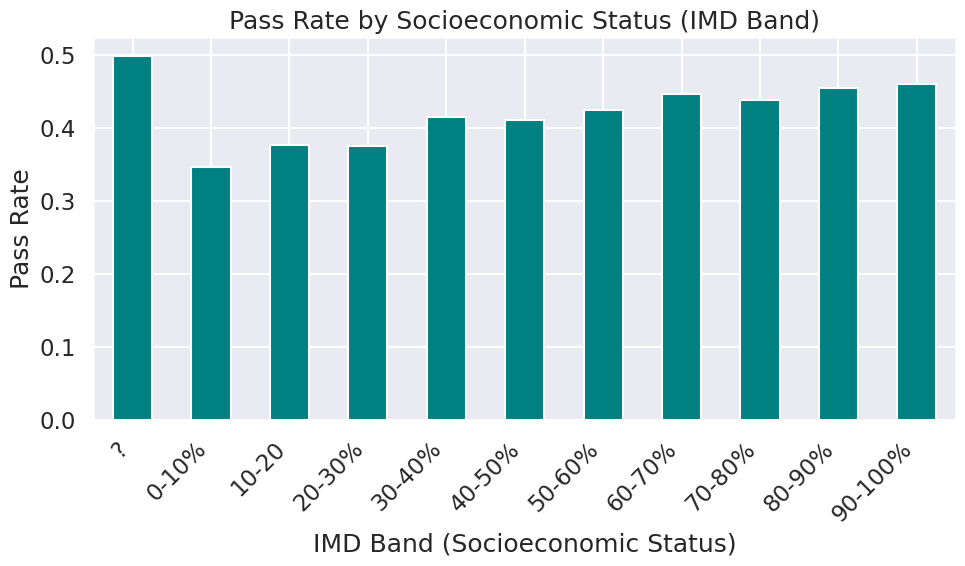

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Ensure data is available ---
# Re-download and unzip the dataset to ensure files are present in the environment
!wget -q "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
!unzip -o -q data_oulad.zip -d data_oulad # Use -o for overwrite without prompt, -q for quiet

# --- Re-create df DataFrame (as it was used in previous sections) ---
# Load the data if not already loaded
df_info = pd.read_csv('/content/data_oulad/studentInfo.csv')
df_vle = pd.read_csv('/content/data_oulad/studentVle.csv')

# Aggregate total clicks for each student
student_total_clicks = df_vle.groupby('id_student')['sum_click'].sum().reset_index()
student_total_clicks.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

# Merge student information with total clicks
df = pd.merge(df_info, student_total_clicks, on='id_student', how='inner')
# --- End of df re-creation ---

# 1. Bar Chart: Pass Rate by IMD Band (Socioeconomic Status)

# Calculate imd_res: crosstab of imd_band vs final_result, normalize to get proportions
imd_res = pd.crosstab(df['imd_band'], df['final_result'], normalize='index')

# Define the correct order for imd_band
def get_numeric_imd_band(band_str):
    if pd.isna(band_str): return -1 # Handle NaN if any
    if '-' in band_str:
        return float(band_str.split('-')[0]) # Take the lower bound for sorting
    return 0 # Default for any other formats if they exist

# Get unique IMD bands and sort them numerically
sorted_imd_bands = sorted(df['imd_band'].dropna().unique(), key=get_numeric_imd_band)

# Filter imd_res to include only 'Pass' and ensure index is ordered
imd_pass_rate = imd_res['Pass'].reindex(sorted_imd_bands)

plt.figure(figsize=(10, 6))
imd_pass_rate.plot(kind='bar', color='teal')
plt.title('Pass Rate by Socioeconomic Status (IMD Band)')
plt.xlabel('IMD Band (Socioeconomic Status)')
plt.ylabel('Pass Rate')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better fit
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('bias_imd_pass_rate.png')
plt.show()

## Fig: Engagment Vs. Disability

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Ensure data is available ---
# Re-download and unzip the dataset to ensure files are present in the environment

import os
if not os.path.exists('/content/data_oulad/'):
    !wget -q "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
    !unzip -o -q data_oulad.zip -d data_oulad # Use -o for overwrite without prompt, -q for quiet

# --- Re-create df DataFrame (as it was used in previous sections) ---
# Load the data if not already loaded
df_info = pd.read_csv('/content/data_oulad/studentInfo.csv')
df_vle = pd.read_csv('/content/data_oulad/studentVle.csv')

# Aggregate total clicks for each student
student_total_clicks = df_vle.groupby('id_student')['sum_click'].sum().reset_index()
student_total_clicks.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

# Merge student information with total clicks
df = pd.merge(df_info, student_total_clicks, on='id_student', how='inner')
# --- End of df re-creation ---


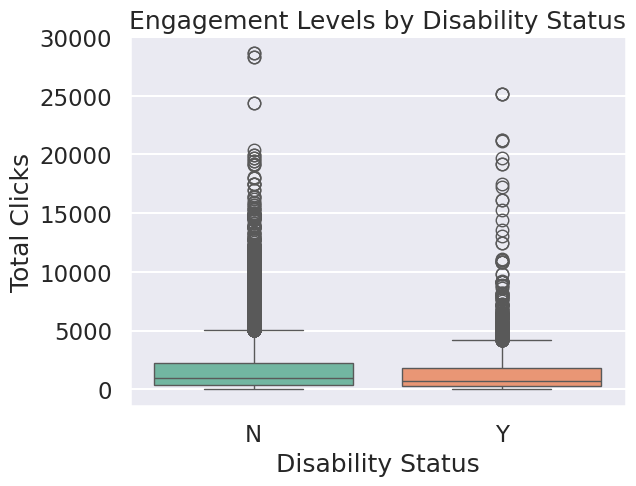

In [ ]:
# 2. Box Plot: Engagement vs. Disability
sns.boxplot(data=df, x='disability', y='total_clicks', hue='disability', palette='Set2', legend=False)
plt.xlabel('Disability Status')
plt.ylabel('Total Clicks')
plt.title('Engagement Levels by Disability Status')
plt.savefig('bias_disability_engagement.png')
plt.show()

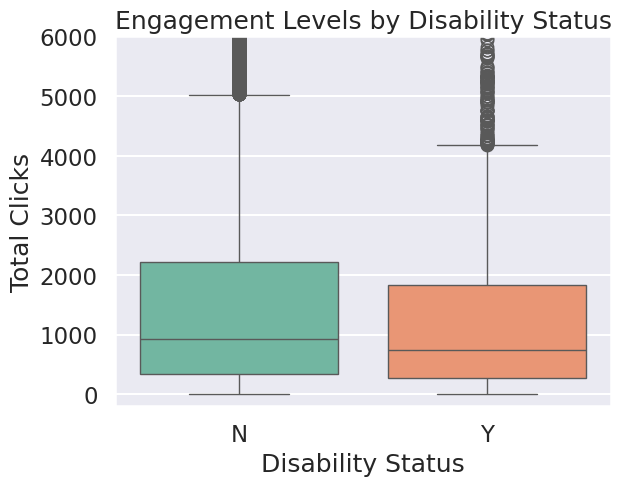

In [ ]:
# 2. Box Plot: Engagement vs. Disability
sns.boxplot(data=df, x='disability', y='total_clicks', hue='disability', palette='Set2', legend=False)
plt.title('Engagement Levels by Disability Status')
plt.xlabel('Disability Status')
plt.ylabel('Total Clicks')
plt.ylim(-200,6000)
plt.savefig('bias_disability_engagement.png')
plt.show()

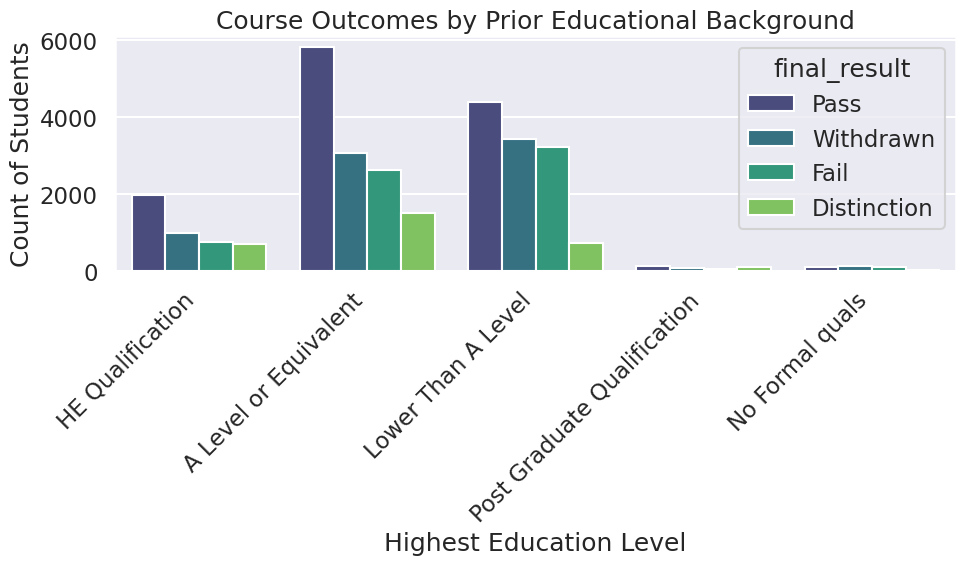

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Ensure data is available ---
# Re-download and unzip the dataset to ensure files are present in the environment
!wget -q "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
!unzip -o -q data_oulad.zip -d data_oulad # Use -o for overwrite without prompt, -q for quiet

# --- Re-create df DataFrame (as it was used in previous sections) ---
# Load the data if not already loaded
df_info = pd.read_csv('/content/data_oulad/studentInfo.csv')
df_vle = pd.read_csv('/content/data_oulad/studentVle.csv')

# Aggregate total clicks for each student
student_total_clicks = df_vle.groupby('id_student')['sum_click'].sum().reset_index()
student_total_clicks.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

# Merge student information with total clicks
df = pd.merge(df_info, student_total_clicks, on='id_student', how='inner')
# --- End of df re-creation ---

# 3. Grouped Bar: Education Level vs. Outcome
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='highest_education', hue='final_result', palette='viridis')
plt.title('Course Outcomes by Prior Educational Background')
plt.xlabel('Highest Education Level')
plt.ylabel('Count of Students')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bias_education_outcomes.png')
plt.show()

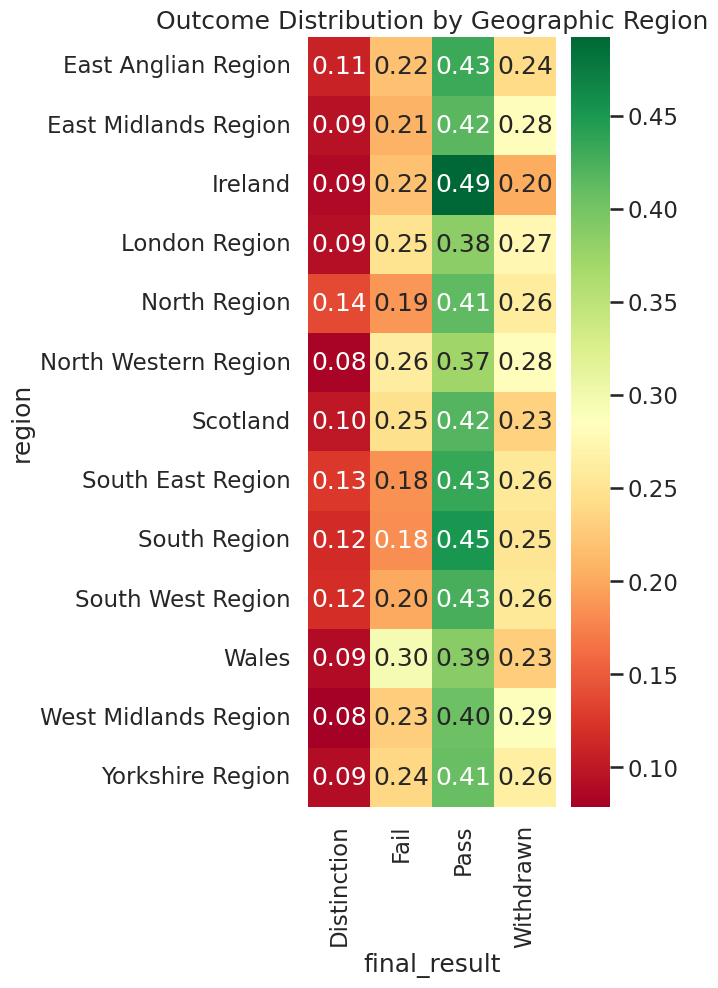

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Ensure data is available ---
# Re-download and unzip the dataset to ensure files are present in the environment
!wget -q "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
!unzip -o -q data_oulad.zip -d data_oulad # Use -o for overwrite without prompt, -q for quiet

# --- Re-create df DataFrame (as it was used in previous sections) ---
# Load the data if not already loaded
df_info = pd.read_csv('/content/data_oulad/studentInfo.csv')
df_vle = pd.read_csv('/content/data_oulad/studentVle.csv')

# Aggregate total clicks for each student
student_total_clicks = df_vle.groupby('id_student')['sum_click'].sum().reset_index()
student_total_clicks.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

# Merge student information with total clicks
df = pd.merge(df_info, student_total_clicks, on='id_student', how='inner')
# --- End of df re-creation ---

# 4. Heatmap: Region vs. Result
reg_res = pd.crosstab(df['region'], df['final_result'], normalize='index')
plt.figure(figsize=(4, 10)) # Adjust figure size for better readability
sns.heatmap(reg_res, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Outcome Distribution by Geographic Region')
plt.savefig('bias_region_heatmap.png')
plt.show()

## Summary of Visualizations
## The Socioeconomic Pass Rate (Bar Chart)
This chart tracks the percentage of students who passed the course, grouped by their IMD (Indices of Multiple Deprivation) band.

The Insight: A steady upward trend as you move from "0-10%" (most deprived) to "90-100%" (least deprived) indicates a significant socioeconomic bias.

Why it matters: It highlights that students from lower-income backgrounds might lack the same resources (stable internet, quiet study space, or prior experience) as those from wealthier areas. Educators can use this to justify targeted scholarship or hardware support programs.

## The Accessibility Gap (Box Plot)
This compares the digital engagement (total clicks) of students with and without a declared disability.

The Insight: If the median number of clicks for students with disabilities is significantly lower, it might not mean they are "less engaged"—it could mean the Virtual Learning Environment (VLE) itself is difficult for them to navigate (an accessibility barrier).

Why it matters: It identifies where the digital platform might be failing a specific group. If a student is willing to learn but the website isn't working with their screen reader or mobility tools, their "clicks" will naturally be lower.

## The Education Level Filter (Grouped Bar Chart)
This chart displays how many students succeeded or failed based on their prior level of education (e.g., "A Level" vs. "Post Graduate").

The Insight: It shows if the course is "too advanced" for those with lower prior qualifications. If the "Fail" or "Withdrawn" bars are disproportionately high for the "No Formal Quals" group, the course might lack the necessary introductory "scaffolding."

Why it matters: It helps in designing better onboarding. You might need a "Week 0" refresher module for students who haven't been in a classroom for a long time.

## The Geographic Heatmap (Regional Analysis)
This heatmap shows the distribution of results across different geographic regions.

The Insight: It reveals if certain regions have higher dropout or failure rates. This could be due to local factors like regional internet outages, varying school systems, or even time-zone differences if the course is international.

Why it matters: If one region is consistently underperforming, educators can investigate if there are specific local challenges and perhaps partner with local organizations to provide better support.

## Simple Summary Version
## The Socioeconomic Pass Rate (The "Resource Gap")
This chart looks at students' income levels (IMD bands) and their success rates.

The Summary: It tells us if the course is harder for students from poorer neighborhoods. If the bars get taller as students get wealthier, it means the course might rely on things like expensive high-speed internet or extra private tutoring that not everyone can afford.

The "Equity" Goal: We want these bars to be as level as possible, showing that the course is accessible to everyone regardless of their bank account.

## The Accessibility Gap (The "Digital Barrier" Check)
This compares how much students with disabilities click compared to those without.

The Summary: It’s a check for the website's design. If students with disabilities have much lower "clicks," it might mean the website is frustrating to use with tools like screen readers. They aren't "less motivated"; they are hitting a digital wall.

The "Equity" Goal: The two boxes should look similar. If the "Disability" box is much lower, the course designers need to fix the website's accessibility features.

## The Education Level Filter (The "Starting Line" Chart)
This shows how a student's previous school experience (like having a degree vs. no formal qualifications) predicts their result.

The Summary: It shows if the "starting line" is fair. If almost everyone without prior qualifications is failing or withdrawing, the course is likely skipping over the basics and assuming students already know too much.

The "Equity" Goal: We want to see a healthy number of "Pass" results in every category, showing that the course effectively "levels up" students who started with less experience.

## The Geographic Heatmap (The "Postal Code" Analysis)
This uses a color-coded grid to see if where a student lives in the country (Region) changes their chance of passing.

The Summary: It spots local problems. For example, if one specific region has a "bright red" failure rate, there might be a local issue—like a regional power grid problem, a local holiday that interfered with an exam, or even a specific school district that didn't prepare students well for this subject.

The "Equity" Goal: A "sea of green" across all regions, showing that your location doesn't determine your success.

## Time-Based Engagement Analysis ****

---



****This section examines how student engagement changes over time.

By analyzing daily activity patterns and trends, it reveals how consistency and timing of engagement influence student success.****

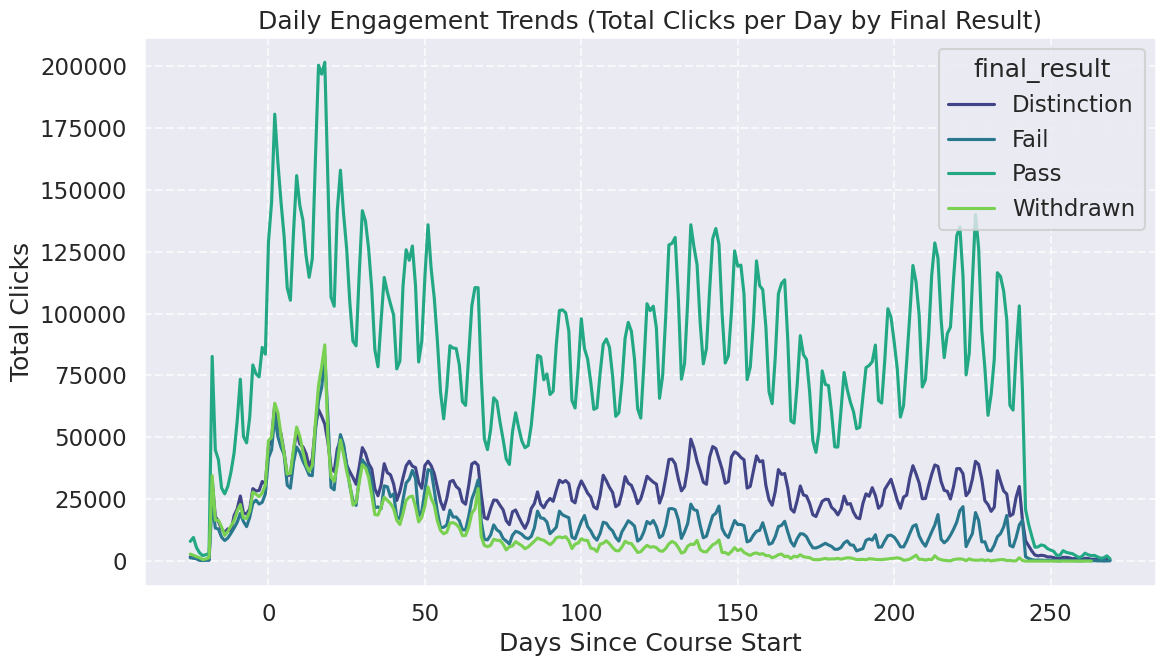

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
if not os.path.exists('/content/data_oulad/'):
    !wget -q "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
    !unzip -o -q data_oulad.zip -d data_oulad # Use -o for overwrite without prompt, -q for quiet

# --- Data Preparation for df_ts ---
# Load required dataframes
df_student_vle = pd.read_csv('/content/data_oulad/studentVle.csv')
df_student_info = pd.read_csv('/content/data_oulad/studentInfo.csv')

# Merge studentVle with studentInfo to get final_result for each click entry
# Ensure column names match for merging: code_module, code_presentation, id_student
df_merged_vle_info = pd.merge(df_student_vle,
                              df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
                              on=['id_student', 'code_module', 'code_presentation'],
                              how='inner')

# Aggregate daily clicks by final_result
# We need to sum 'sum_click' for each 'date' and 'final_result'
df_ts = df_merged_vle_info.groupby(['date', 'final_result'])['sum_click'].sum().reset_index()

# Rename 'sum_click' to 'clicks' for clarity in the plot
df_ts.rename(columns={'sum_click': 'clicks'}, inplace=True)

# Ensure 'date' column is suitable for plotting (it's already days since course start)
df_ts.sort_values(by=['date', 'final_result'], inplace=True)

# 1. Daily Trends: Average clicks per day by outcome
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_ts, x='date', y='clicks', hue='final_result', palette='viridis')
plt.title('Daily Engagement Trends (Total Clicks per Day by Final Result)')
plt.xlabel('Days Since Course Start')
plt.ylabel('Total Clicks')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ts_daily_trends.png')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
if not os.path.exists('/content/data_oulad/'):
    !wget -q "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
    !unzip -o -q data_oulad.zip -d data_oulad # Use -o for overwrite without prompt, -q for quiet

# --- Data Preparation for weekly_pattern ---
# Load required dataframes
df_student_vle = pd.read_csv('/content/data_oulad/studentVle.csv')
df_student_info = pd.read_csv('/content/data_oulad/studentInfo.csv')

# Merge studentVle with studentInfo to get final_result for each click entry
df_merged_vle_info = pd.merge(df_student_vle,
                              df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
                              on=['id_student', 'code_module', 'code_presentation'],
                              how='inner')

# Calculate a 'relative day of week' (0-6) from the 'date' (days since course start)
# This assumes a consistent starting day for all courses, which is a simplification for visualization
df_merged_vle_info['day_of_week_relative'] = df_merged_vle_info['date'] % 7

# Aggregate total clicks by relative day of week and final result
weekly_clicks = df_merged_vle_info.groupby(['day_of_week_relative', 'final_result'])['sum_click'].sum().reset_index()

# Pivot the table to create weekly_pattern suitable for a heatmap
weekly_pattern = weekly_clicks.pivot_table(index='day_of_week_relative', columns='final_result', values='sum_click', fill_value=0)


## Fig: Weakly Heatmap

In [ ]:
weekly_pattern

final_result,Distinction,Fail,Pass,Withdrawn
day_of_week_relative,,,,
0,938815.0,461050.0,2621253.0,349798.0
1,1137447.0,609823.0,3310911.0,430766.0
2,1355432.0,799463.0,4088215.0,544058.0
3,1335642.0,824506.0,4046753.0,570445.0
4,1245359.0,787551.0,3809049.0,540704.0
5,1123947.0,663808.0,3328700.0,419322.0
6,927637.0,450664.0,2550597.0,333384.0


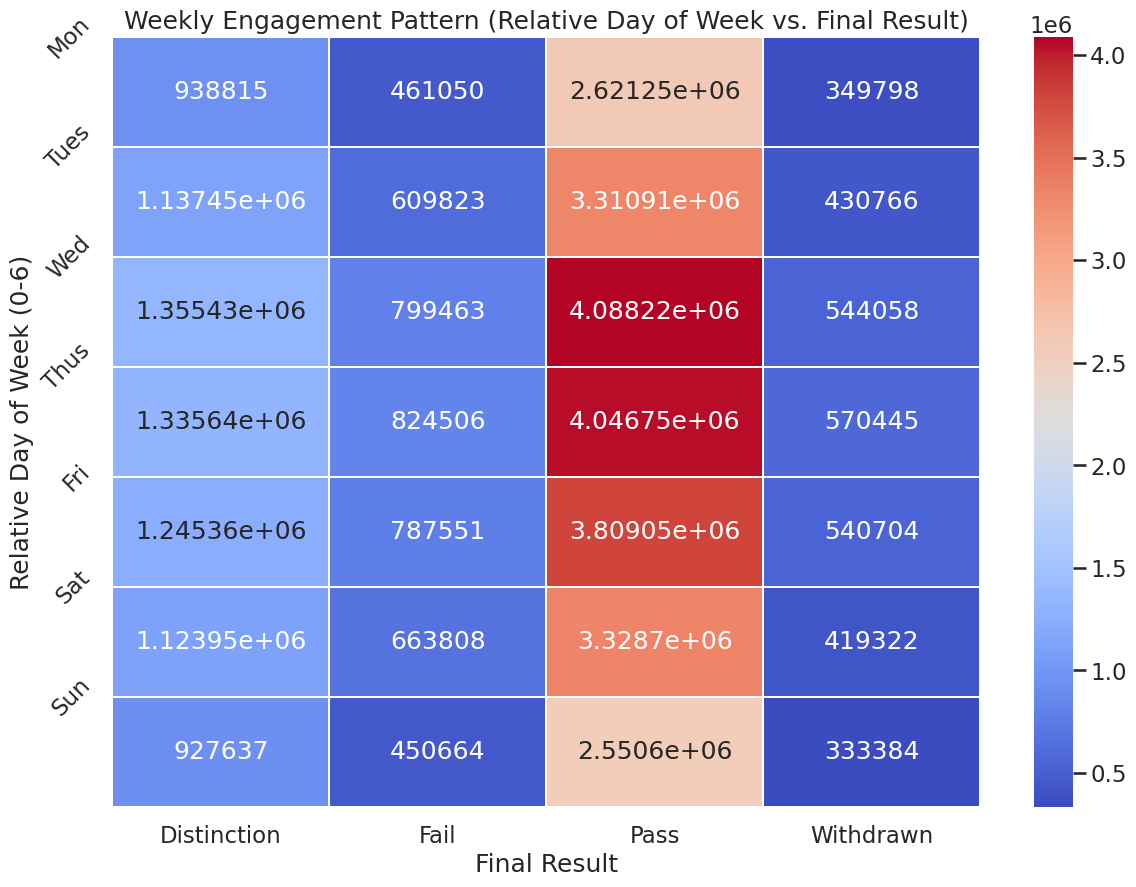

In [ ]:
# 2. Weekly Heatmap: Clicks by day of week vs. student style
plt.figure(figsize=(14, 10))
sns.heatmap(weekly_pattern, annot=True, cmap='coolwarm', fmt='g',linecolor='white', linewidths=0.1)
plt.title(' vs. Final Result)')
plt.xlabel('Final Result')
plt.ylabel('Relative Day of Week (0-6)')
plt.yticks([0,1, 2,3,4,5,6], ['Mon','Tues','Wed','Thus', 'Fri', 'Sat','Sun'],
       rotation=45)
plt.savefig('ts_weekly_heatmap.png')
plt.show()

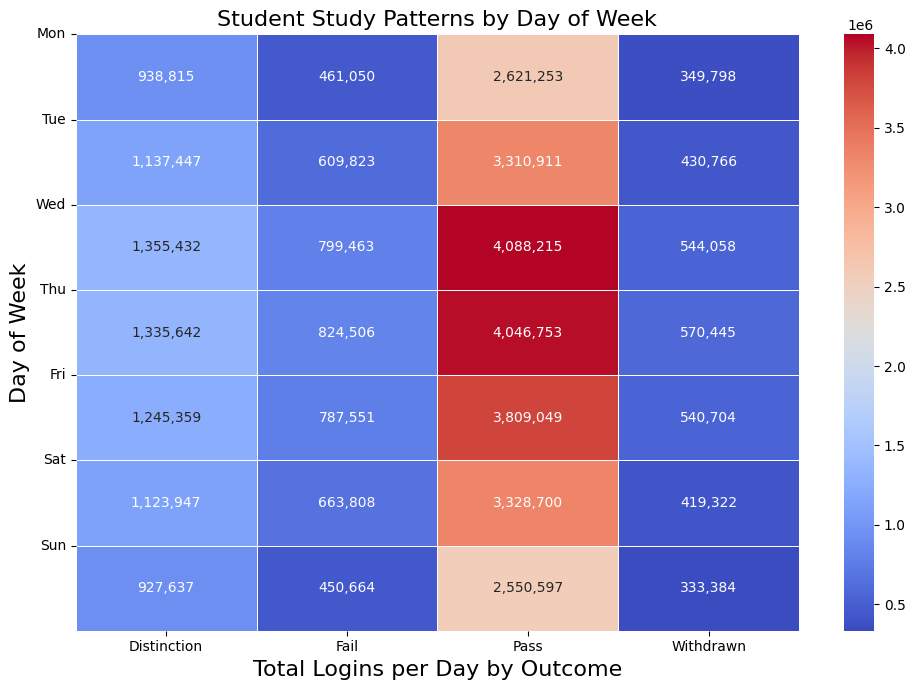

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    weekly_pattern,
    annot=True,
    cmap='coolwarm',
    fmt=',.0f',                 # better number format (1,234,567)
    linewidths=0.5,
    linecolor='white'
)

plt.title('Student Study Patterns by Day of Week', fontsize=16)
plt.xlabel('Total Logins per Day by Outcome', fontsize=16)
plt.ylabel('Day of Week', fontsize=16)

# FIX: Align ticks with index positions
plt.yticks(
    ticks=range(len(weekly_pattern.index)),
    labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    rotation=0
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('ts_weekly_heatmap.png', dpi=300)
plt.show()

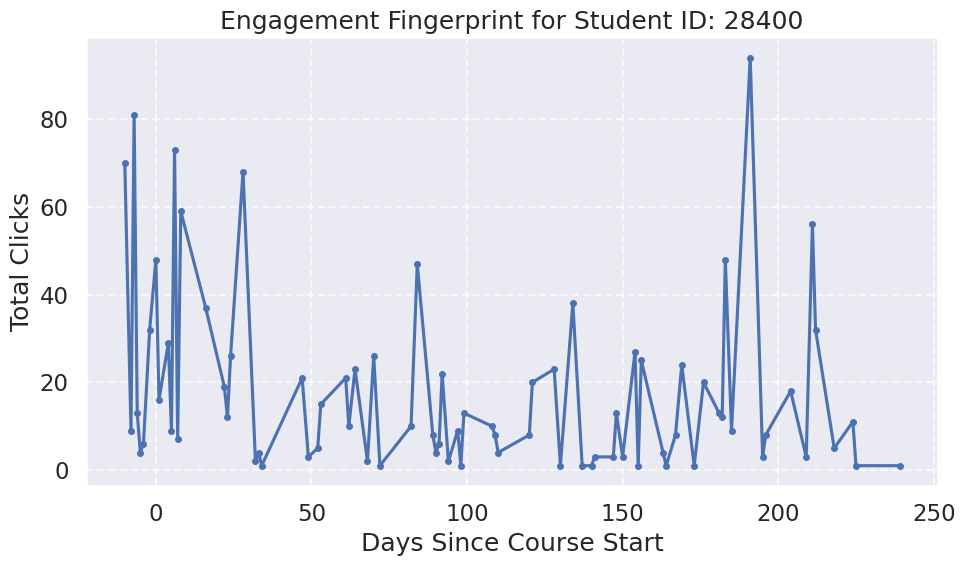

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure data is available ---
# Re-download and unzip the dataset to ensure files are present in the environment
!wget -q "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
!unzip -o -q data_oulad.zip -d data_oulad # Use -o for overwrite without prompt, -q for quiet

# --- Data Preparation for df_merged_vle_info (if not already in kernel state) ---
df_student_vle = pd.read_csv('/content/data_oulad/studentVle.csv')
df_student_info = pd.read_csv('/content/data_oulad/studentInfo.csv')

df_merged_vle_info = pd.merge(df_student_vle,
                              df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
                              on=['id_student', 'code_module', 'code_presentation'],
                              how='inner')

# 3. Fingerprints: Individual student behavior plots
# To plot individual student behavior, we need to select data for a single student.
# Let's pick a sample student_id from our merged DataFrame.

# First, identify unique student IDs
unique_students = df_merged_vle_info['id_student'].unique()

# Choose a sample student (e.g., the first one)
if len(unique_students) > 0:
    sample_student_id = unique_students[0]
    # Filter data for this sample student
    sample_data = df_merged_vle_info[df_merged_vle_info['id_student'] == sample_student_id].copy()

    # Aggregate clicks per day for this student
    sample_data = sample_data.groupby('date')['sum_click'].sum().reset_index()
    sample_data.rename(columns={'date': 'day', 'sum_click': 'clicks'}, inplace=True)

    # Plot the individual student's engagement fingerprint
    plt.figure(figsize=(10, 6))
    plt.plot(sample_data['day'], sample_data['clicks'], marker='o', linestyle='-', markersize=4)
    plt.title(f'Engagement Fingerprint for Student ID: {sample_student_id}')
    plt.xlabel('Days Since Course Start')
    plt.ylabel('Total Clicks')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('ts_fingerprints.png')
    plt.show()
else:
    print("No student data available to plot fingerprints.")

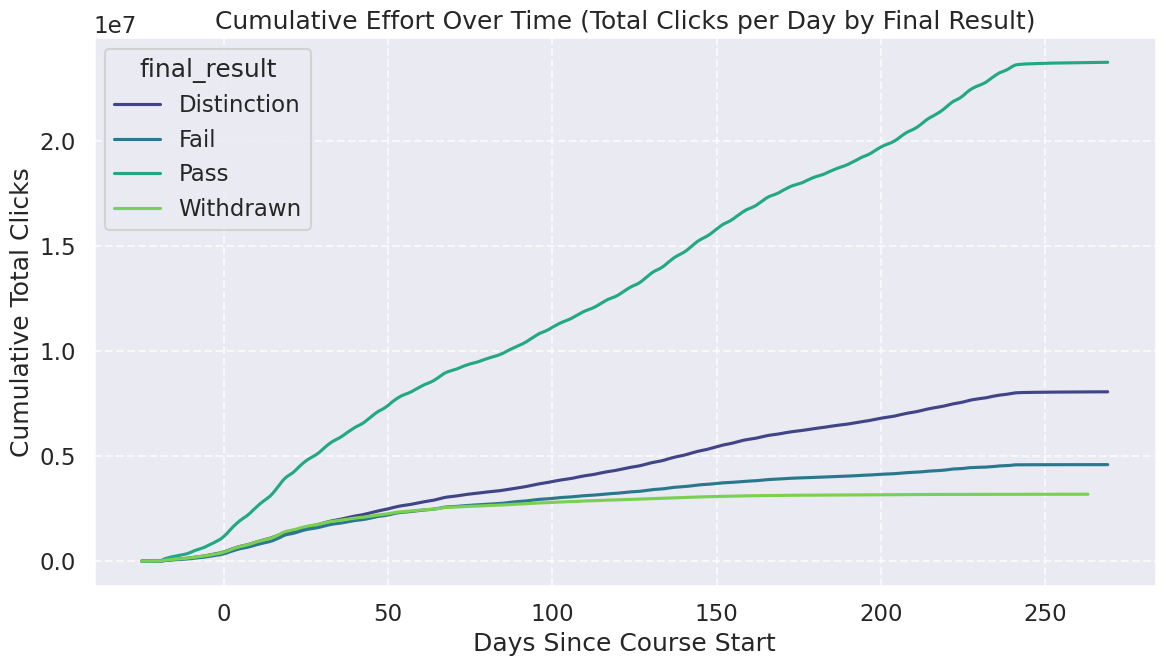

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Ensure data is available ---
# Re-download and unzip the dataset to ensure files are present in the environment
!wget -q "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
!unzip -o -q data_oulad.zip -d data_oulad # Use -o for overwrite without prompt, -q for quiet

# --- Data Preparation for df_ts ---
# Load required dataframes
df_student_vle = pd.read_csv('/content/data_oulad/studentVle.csv')
df_student_info = pd.read_csv('/content/data_oulad/studentInfo.csv')

# Merge studentVle with studentInfo to get final_result for each click entry
# Ensure column names match for merging: code_module, code_presentation, id_student
df_merged_vle_info = pd.merge(df_student_vle,
                              df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
                              on=['id_student', 'code_module', 'code_presentation'],
                              how='inner')

# Aggregate daily clicks by final_result
# We need to sum 'sum_click' for each 'date' and 'final_result'
df_ts = df_merged_vle_info.groupby(['date', 'final_result'])['sum_click'].sum().reset_index()

# Rename 'sum_click' to 'clicks' for clarity in the plot
df_ts.rename(columns={'sum_click': 'clicks'}, inplace=True)

# Calculate cumulative clicks for each final_result category
df_ts['cumulative_clicks'] = df_ts.groupby('final_result')['clicks'].cumsum()

# 4. Cumulative Effort: Total clicks since start
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_ts, x='date', y='cumulative_clicks', hue='final_result', palette='viridis')
plt.title('Cumulative Effort Over Time (Total Clicks per Day by Final Result)')
plt.xlabel('Days Since Course Start')
plt.ylabel('Cumulative Total Clicks')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ts_cumulative_effort.png')
plt.show()

## Summary of Visualizations
## Daily Engagement Trends (The "Pulse" of the Class)
This chart shows the average daily activity for different groups of students (Pass, Fail, Withdrawn).

The Summary: It shows you the "energy" of the class. Usually, you’ll see peaks on days when an assignment is due and valleys during the holidays.

The "Success" Sign: A steady, active line that stays high throughout the course. If the line for a group of students starts to "flatline" (drop to zero) early on, you know exactly when they lost interest.

## The Weekly Engagement Heatmap (The "Routine" Grid)
This grid uses colors to show which days of the week different types of students are most active.

The Summary: It reveals the habits of your students. For example, "Consistent" students might have a light blue color every single day, while "Crammers" might have a dark blue "hot spot" only on Sundays.

The "Success" Sign: Darker colors spread across the whole week. Students with a "rhythm" (studying a little bit every day) almost always perform better than those who only study in short, intense bursts.

## Engagement Fingerprints (The "Individual Story")
These are "zoomed-in" charts that show the actual behavior of just one student from each group.

The Summary: It humanizes the data. You can see the "Steady Learner" who logs in every morning, the "Crammer" who disappears for three weeks and then works 18 hours straight, and the "Dropout" who simply stops one Tuesday and never comes back.

The "Success" Sign: Seeing a "Fingerprint" that shows regular, frequent spikes. If a student's fingerprint starts to look like a "Dropout's" (long flat lines), it's time to call them.

## Cumulative Effort (The "Snowball" Effect)
This tracks the total amount of work a student has done from the first day until now.

The Summary: It shows how effort builds up. At the start of the course, everyone looks the same. But by the middle of the semester, the "Pass" students have built up a huge lead in total clicks, while the "Fail" students are falling further and further behind.

The "Success" Sign: A line that keeps curving upward. If the line starts to level off (like a plateau), it means the student has stopped adding new effort and is "stalling out."

## Social and Collaborative Analysis

*****This section explores how student participation in forum-based and collaborative activity relates to academic performance.

It analyzes patterns such as posting behavior, reading activity, and different types of student participation.******

### Note on Social Data *****

This section uses simulated data to demonstrate how forum activity might relate to student performance. It is included as an extension of the main analysis.

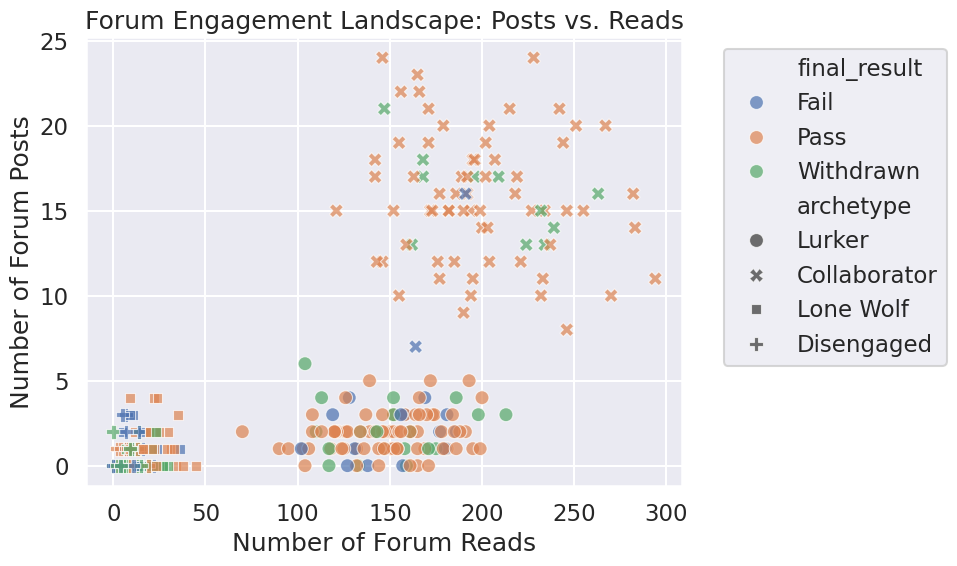

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)
n_students = 300

# Generate Social/Collaborative Data
data_social = []
for sid in range(n_students):
    archetype = np.random.choice(['Collaborator', 'Lurker', 'Lone Wolf', 'Disengaged'], p=[0.2, 0.4, 0.2, 0.2])

    if archetype == 'Collaborator':
        posts = np.random.poisson(15)
        reads = np.random.normal(200, 40)
        pass_prob = 0.85
    elif archetype == 'Lurker':
        posts = np.random.poisson(2)
        reads = np.random.normal(150, 30)
        pass_prob = 0.70
    elif archetype == 'Lone Wolf':
        posts = np.random.poisson(1)
        reads = np.random.normal(20, 10)
        pass_prob = 0.60
    else: # Disengaged
        posts = np.random.poisson(0.5)
        reads = np.random.normal(10, 5)
        pass_prob = 0.30

    result = np.random.choice(['Pass', 'Fail', 'Withdrawn'], p=[pass_prob, (1-pass_prob)*0.4, (1-pass_prob)*0.6])
    score = np.random.normal(75 if result == 'Pass' else 45, 10)

    data_social.append({
        'student_id': sid,
        'forum_posts': max(0, int(posts)),
        'forum_reads': max(0, int(reads)),
        'archetype': archetype,
        'final_result': result,
        'final_score': max(0, min(100, score))
    })

df_social = pd.DataFrame(data_social)
df_social.to_csv('student_social_data.csv', index=False)

# Chart 1: Scatter Plot - Posts vs. Reads
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_social, x='forum_reads', y='forum_posts', hue='final_result', style='archetype', s=100, alpha=0.7)
plt.title('Forum Engagement Landscape: Posts vs. Reads')
plt.xlabel('Number of Forum Reads')
plt.ylabel('Number of Forum Posts')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('social_engagement_scatter.png')
plt.show()

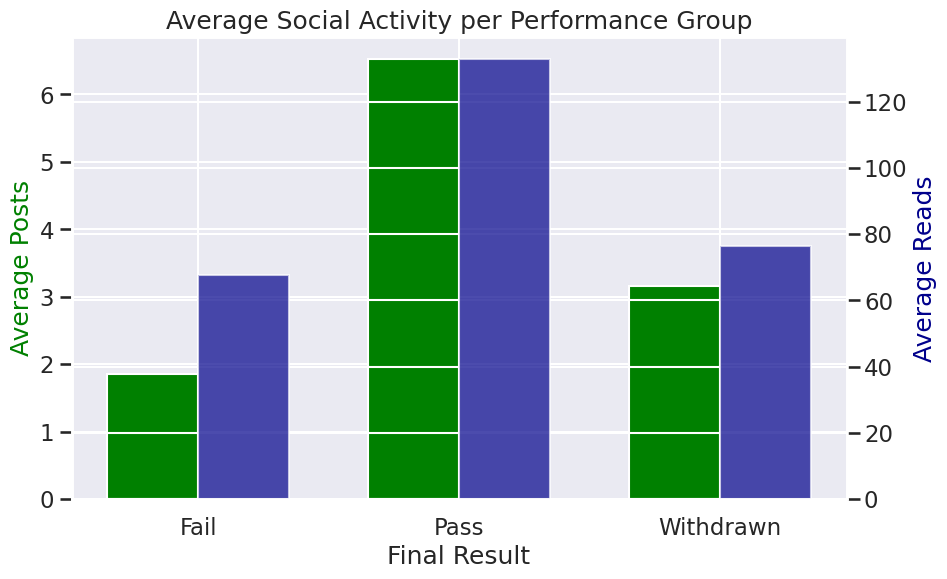

In [ ]:
# Chart 2: Bar Chart - Average Activity by Result (Manual Dual Axis)
avg_data = df_social.groupby('final_result')[['forum_posts', 'forum_reads']].mean()
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

width = 0.35
x = np.arange(len(avg_data.index))

ax1.bar(x - width/2, avg_data['forum_posts'], width, label='Avg Posts', color='green')
ax2.bar(x + width/2, avg_data['forum_reads'], width, label='Avg Reads', color='darkblue', alpha=0.7)

ax1.set_xlabel('Final Result')
ax1.set_ylabel('Average Posts', color='green')
ax2.set_ylabel('Average Reads', color='darkblue')
ax1.set_xticks(x)
ax1.set_xticklabels(avg_data.index)
plt.title('Average Social Activity per Performance Group')
plt.savefig('social_avg_activity_bar.png')
plt.show()

/tmp/ipykernel_11547/4162147392.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_social, x='final_result', y='forum_posts', palette='Set3')


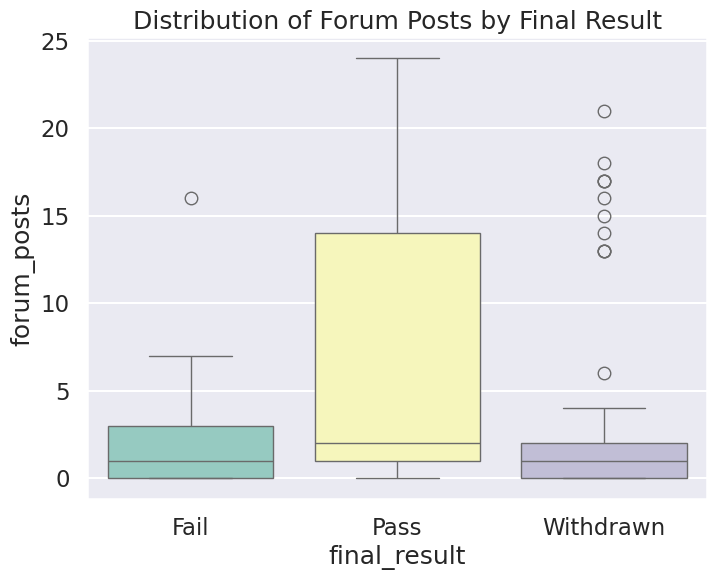

In [ ]:
# Chart 3: Box Plot - Forum Posts vs Outcome
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_social, x='final_result', y='forum_posts', palette='Set3')
plt.title('Distribution of Forum Posts by Final Result')
plt.savefig('social_posts_boxplot.png')
plt.show()

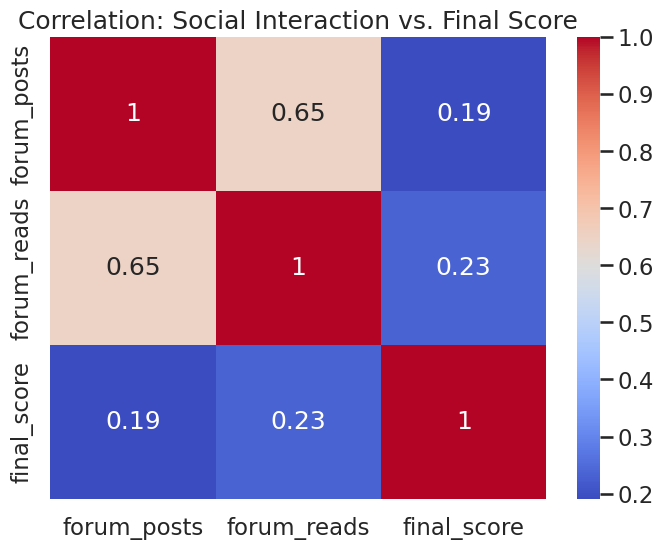

In [ ]:
# Chart 4: Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_social[['forum_posts', 'forum_reads', 'final_score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation: Social Interaction vs. Final Score')
plt.savefig('social_correlation_heatmap.png')
plt.show()

## Summary of Visualizations
## The Forum Engagement Landscape (Scatter Plot)
This plot places every student on a map based on how much they post (y-axis) versus how much they read (x-axis).

The Insight: It identifies distinct student archetypes. You’ll see "Collaborators" in the top-right (high posts, high reads), "Lurkers" along the bottom-right (high reads, low posts), and "Lone Wolves" in the bottom-left.

Why it matters: It shows that not all "quiet" students are the same. A "Lurker" who reads everything but never posts can still be highly successful, whereas a "Disengaged" student who doesn't read or post is at much higher risk.

## Average Social Activity by Result (Dual-Axis Bar Chart)
This chart compares the average number of posts and reads for students who Passed, Failed, or Withdrew.

The Insight: It clearly shows the "social gap." Successful students usually have much higher average "reads" than "posts," indicating that staying informed of class discussions is a key success factor, even if they aren't the most vocal contributors.

Why it matters: It proves that listening (reading) is just as important as talking (posting). Educators can encourage students to at least "lurk" in the forums to stay connected to the course material and community.

## The "Voice" of the Student (Box Plot)
This box plot focuses specifically on the distribution of forum posts across different outcomes.

The Insight: It shows that while highly vocal students (high posts) almost always pass, there is a wide range of posting behavior among successful students.

Why it matters: It helps set realistic expectations. Posting 20 times doesn't guarantee a pass, but students who post zero times are much more common in the "Fail" and "Withdrawn" groups.

## Social Correlation Heatmap
This heatmap calculates the statistical link between forum activity and the final exam score.

The Insight: It quantifies the relationship. For example, if "forum_reads" has a correlation of 0.65 with "final_score," it's a strong indicator that keeping up with discussions is a reliable predictor of academic performance.

Why it matters: Educators can use this data to back up their advice. Instead of just saying "use the forums," they can say: "Our data shows a 65% positive correlation between reading forum threads and higher final scores."

##Simple Summary Version
## The Forum Landscape (The "Who's Who" Map)
The Summary: This chart plots students based on their talking (posting) vs. listening (reading).

The "Success" Sign: Students in the top-right are your leaders, but a large cluster in the bottom-right (Lurkers) is also a good sign—it means students are paying attention to the community.

## Average Activity Bar (The "Community Pulse")
The Summary: This shows the "average" social life of a student in each result group.

The "Success" Sign: The "Pass" bars should be much taller than the "Withdrawn" bars. It shows that being part of the online "crowd" helps keep students on track.

## The "Voice" Box Plot (The "Participation" Check)
The Summary: This looks at how much students speak up.

The "Success" Sign: While not everyone has to be a "chatterbox" to pass, successful students usually have a higher "floor" of activity—they at least check in occasionally.

## The Social Correlation Heatmap (The "Connection" Score)
The Summary: This turns "socializing" into a number. It tells you exactly how much your grade is likely to go up as your forum activity increases.

The "Success" Sign: Bright, warm colors connecting "reads" and "posts" to the "final score."

#**Machine Learning**

## Objective

This section applies machine learning techniques to predict student performance in the OULAD dataset. The main goal is to determine whether demographic, academic, and early engagement variables can be used to identify student outcomes.

Two prediction tasks are considered:

1. **Multiclass classification** to predict the final result (`Distinction`, `Pass`, `Fail`, `Withdrawn`)
2. **Binary early warning classification** to identify students who are academically at risk

To make the analysis more realistic, the predictive features are constructed from the early part of the course rather than from the full course duration.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Data Preparation
The following code loads the required OULAD tables and prepares them for machine learning analysis.

In [ ]:
import os
path = "/content/data_oulad/"
# if path exist do none, if not load the dataset again
if not os.path.exists(path):
  !wget "https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip" -O data_oulad.zip
  !unzip data_oulad.zip -d data_oulad


--2026-04-17 18:38:22--  https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data_oulad.zip’

data_oulad.zip          [    <=>             ]  44.58M  65.3MB/s    in 0.7s    

2026-04-17 18:38:23 (65.3 MB/s) - ‘data_oulad.zip’ saved [46748244]

Archive:  data_oulad.zip
  inflating: data_oulad/assessments.csv  
  inflating: data_oulad/courses.csv  
  inflating: data_oulad/studentAssessment.csv  
  inflating: data_oulad/studentInfo.csv  
  inflating: data_oulad/studentRegistration.csv  
  inflating: data_oulad/studentVle.csv  
  inflating: data_oulad/vle.csv      
  inflating: data_oulad/OULAD.names  


In [ ]:
studentInfo = pd.read_csv(path + "studentInfo.csv")
studentVle = pd.read_csv(path + "studentVle.csv")
studentAssessment = pd.read_csv(path + "studentAssessment.csv")
assessments = pd.read_csv(path + "assessments.csv")
courses = pd.read_csv(path + "courses.csv")
studentRegistration = pd.read_csv(path + "studentRegistration.csv")

## Early-Course Feature Construction

To reduce data leakage and make prediction more useful for intervention, only the first 20% of each course presentation is used to construct the main engagement and assessment features.

In [ ]:
studentInfo = studentInfo.merge(
    courses,
    on=['code_module', 'code_presentation'],
    how='left'
)

studentInfo['cutoff_20'] = (0.20 * studentInfo['module_presentation_length']).round().astype(int)

studentInfo[['code_module', 'code_presentation', 'module_presentation_length', 'cutoff_20']].head()

,code_module,code_presentation,module_presentation_length,cutoff_20
0,AAA,2013J,268,54
1,AAA,2013J,268,54
2,AAA,2013J,268,54
3,AAA,2013J,268,54
4,AAA,2013J,268,54


In [ ]:
studentInfo = studentInfo.merge(
    courses.drop(columns=['module_presentation_length']),
    on=['code_module', 'code_presentation'],
    how='left'
)
studentInfo['cutoff_20'] = (0.20 * studentInfo['module_presentation_length']).round().astype(int)

studentInfo[['code_module', 'code_presentation', 'module_presentation_length', 'cutoff_20']].head()

,code_module,code_presentation,module_presentation_length,cutoff_20
0,AAA,2013J,268,54
1,AAA,2013J,268,54
2,AAA,2013J,268,54
3,AAA,2013J,268,54
4,AAA,2013J,268,54


In [ ]:
vle_early = studentVle.merge(
    studentInfo[['id_student', 'code_module', 'code_presentation', 'cutoff_20']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

vle_early = vle_early[vle_early['date'] <= vle_early['cutoff_20']].copy()

vle_features_20 = vle_early.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg({
    'sum_click': ['sum', 'mean', 'count'],
    'date': 'nunique'
}).reset_index()

vle_features_20.columns = [
    'id_student', 'code_module', 'code_presentation',
    'early_total_clicks', 'early_avg_clicks', 'early_vle_records', 'early_days_active'
]

vle_features_20.head()

,id_student,code_module,code_presentation,early_total_clicks,early_avg_clicks,early_vle_records,early_days_active
0,6516,AAA,2014J,1001,4.789474,209,44
1,8462,DDD,2013J,516,2.356164,219,35
2,8462,DDD,2014J,10,2.500000,4,1
3,11391,AAA,2013J,529,5.877778,90,18
4,23629,BBB,2013B,61,2.541667,24,7


In [ ]:
assess_full = studentAssessment.merge(
    assessments,
    on='id_assessment',
    how='left'
)

assess_full = assess_full.merge(
    studentInfo[['id_student', 'code_module', 'code_presentation', 'cutoff_20']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

# Convert columns to numeric
assess_full['score'] = pd.to_numeric(assess_full['score'], errors='coerce')
assess_full['date'] = pd.to_numeric(assess_full['date'], errors='coerce')
assess_full['cutoff_20'] = pd.to_numeric(assess_full['cutoff_20'], errors='coerce')

# Keep only early assessments
assess_early = assess_full[assess_full['date'] <= assess_full['cutoff_20']].copy()

assess_features_20 = assess_early.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg({
    'score': ['mean', 'max', 'count'],
    'assessment_type': lambda x: (x == 'TMA').sum()
}).reset_index()

assess_features_20.columns = [
    'id_student', 'code_module', 'code_presentation',
    'early_avg_assess_score', 'early_max_assess_score',
    'early_num_assessments', 'early_num_tma'
]

assess_features_20.head()

,id_student,code_module,code_presentation,early_avg_assess_score,early_max_assess_score,early_num_assessments,early_num_tma
0,6516,AAA,2014J,54.0,60.0,2,2
1,8462,DDD,2013J,93.0,93.0,1,1
2,8462,DDD,2014J,88.0,93.0,2,2
3,11391,AAA,2013J,81.5,85.0,2,2
4,23629,BBB,2013B,65.0,67.0,2,2


In [ ]:
studentRegistration = studentRegistration.replace('?', np.nan)

studentRegistration['date_registration'] = pd.to_numeric(studentRegistration['date_registration'], errors='coerce')
studentRegistration['date_unregistration'] = pd.to_numeric(studentRegistration['date_unregistration'], errors='coerce')

studentRegistration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


## Modeling Dataset

All demographic, registration, early engagement, and early assessment features are merged into one final table for prediction.

In [ ]:
df_ml = studentInfo.merge(
    studentRegistration,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

df_ml = df_ml.merge(
    vle_features_20,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

df_ml = df_ml.merge(
    assess_features_20,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

fill_zero_cols = [
    'early_total_clicks', 'early_avg_clicks', 'early_vle_records', 'early_days_active',
    'early_avg_assess_score', 'early_max_assess_score', 'early_num_assessments', 'early_num_tma'
]

for col in fill_zero_cols:
    df_ml[col] = df_ml[col].fillna(0)

df_ml['imd_band'] = df_ml['imd_band'].replace('?', np.nan)

df_ml['at_risk'] = df_ml['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

df_ml = df_ml.dropna(subset=['final_result']).copy()

print(df_ml.shape)
df_ml.head()

(32593, 25)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_unregistration,early_total_clicks,early_avg_clicks,early_vle_records,early_days_active,early_avg_assess_score,early_max_assess_score,early_num_assessments,early_num_tma,at_risk
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,NaN,529.0,5.877778,90.0,18.0,81.5,85.0,2.0,2.0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,NaN,669.0,3.716667,180.0,26.0,69.0,70.0,2.0,2.0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,12.0,281.0,3.697368,76.0,12.0,0.0,0.0,0.0,0.0,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,NaN,804.0,3.281633,245.0,40.0,71.5,72.0,2.0,2.0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,NaN,601.0,3.828025,157.0,26.0,49.5,69.0,2.0,2.0,0


## Task 1: Multiclass Prediction of Final Result

The first task predicts the final course outcome among four categories: `Distinction`, `Pass`, `Fail`, and `Withdrawn`.

### Model Selection Rationale

Four different models were selected to compare performance across different learning approaches.

Logistic Regression serves as a baseline linear model, providing interpretability and simplicity.

Random Forest is a bagging-based ensemble method that reduces variance and improves robustness.

Gradient Boosting and AdaBoost are boosting techniques that iteratively improve weak learners and capture complex non-linear relationships.

By comparing these models, we aim to identify which approach best captures patterns in student behavior and performance.

In [ ]:
features = [
    'code_module', 'code_presentation',
    'gender', 'region', 'highest_education', 'imd_band', 'age_band',
    'num_of_prev_attempts', 'studied_credits', 'disability',
    'date_registration',
    'early_total_clicks', 'early_avg_clicks', 'early_vle_records', 'early_days_active',
    'early_avg_assess_score', 'early_max_assess_score', 'early_num_assessments', 'early_num_tma'
]

X_multi = df_ml[features].copy()
y_multi = df_ml['final_result'].copy()

X_multi = pd.get_dummies(X_multi, drop_first=True)
X_multi = X_multi.fillna(0)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

print(X_train_m.shape, X_test_m.shape)

(26074, 49) (6519, 49)


In [ ]:
models_multi = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

multi_results = []

for name, model in models_multi.items():
    model.fit(X_train_m, y_train_m)
    preds = model.predict(X_test_m)
    acc = accuracy_score(y_test_m, preds)

    multi_results.append({
        'Model': name,
        'Accuracy': acc
    })

multi_results_df = pd.DataFrame(multi_results).sort_values(by='Accuracy', ascending=False)
multi_results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy
2,Gradient Boosting,0.606381
1,Random Forest,0.600245
0,Logistic Regression,0.577236
3,AdaBoost,0.560055


### Multiclass Model Comparison Interpretation

The table above compares the accuracy of four machine learning models in predicting student final outcomes.

Gradient Boosting achieved the highest accuracy (60.6%), followed closely by Random Forest (60.0%). Logistic Regression and AdaBoost performed slightly worse.

This indicates that ensemble models, which combine multiple decision trees, are more effective in capturing complex patterns in student behavior and performance than simpler linear models.

However, the overall accuracy is moderate, suggesting that predicting exact final outcomes across four categories is a challenging task.

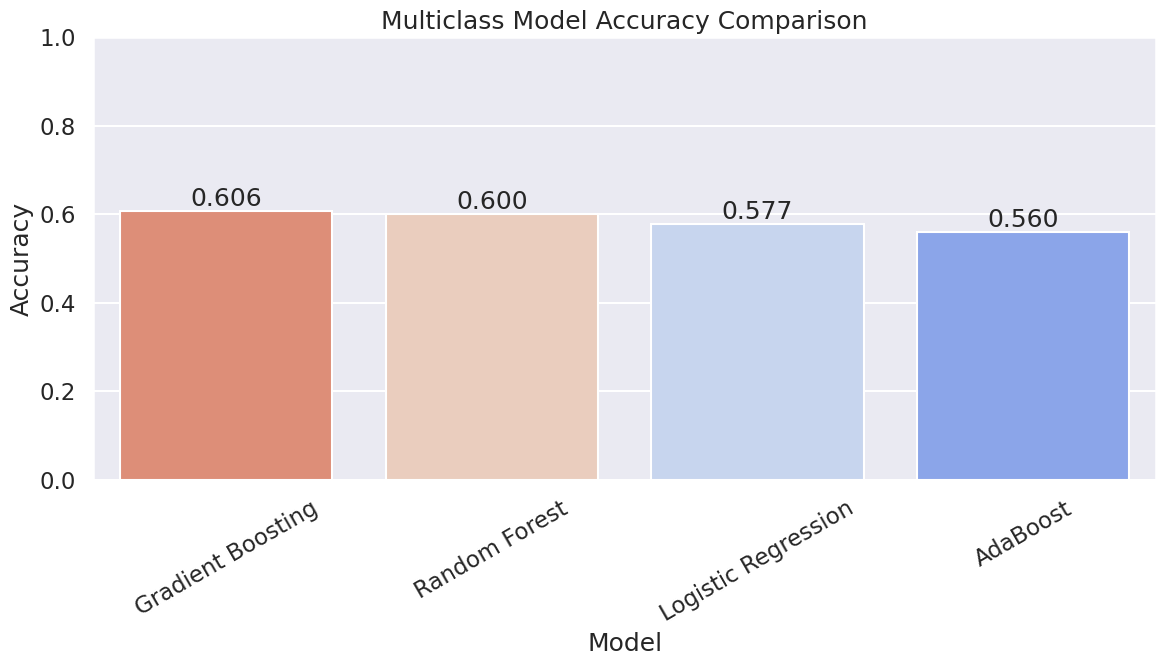

In [ ]:
sns.set_theme('talk')

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=multi_results_df, x='Model', y='Accuracy', hue='Model', palette='coolwarm_r', legend=False)
plt.title('Multiclass Model Accuracy Comparison')
plt.xticks(rotation=30)
plt.ylim(0, 1)

# Add values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

### Visualization Insight

The bar chart visually confirms that Gradient Boosting and Random Forest outperform the other models.

The small gap between models suggests that all models are learning similar patterns, but ensemble methods provide a slight advantage.

In [ ]:
best_multi_name = multi_results_df.iloc[0]['Model']
best_multi_model = models_multi[best_multi_name]

best_multi_model.fit(X_train_m, y_train_m)
best_multi_preds = best_multi_model.predict(X_test_m)

print("Best multiclass model:", best_multi_name)
print(classification_report(y_test_m, best_multi_preds))

labels_multi = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
cm_multi = confusion_matrix(y_test_m, best_multi_preds, labels=labels_multi)

Best multiclass model: Gradient Boosting
              precision    recall  f1-score   support

 Distinction       0.58      0.21      0.31       605
        Fail       0.47      0.28      0.35      1411
        Pass       0.58      0.85      0.69      2472
   Withdrawn       0.73      0.65      0.69      2031

    accuracy                           0.61      6519
   macro avg       0.59      0.50      0.51      6519
weighted avg       0.60      0.61      0.58      6519



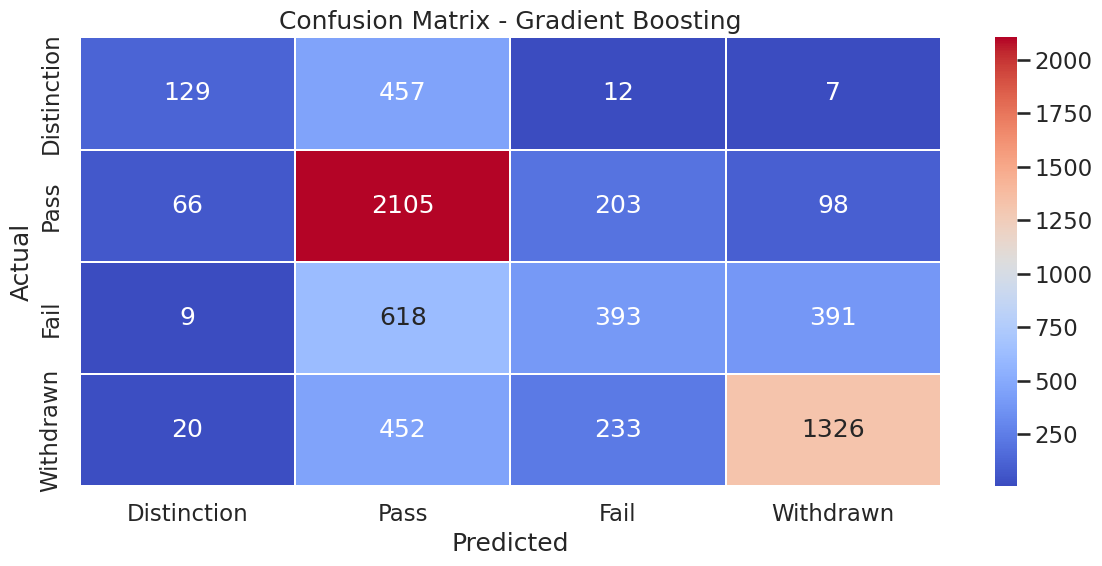

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='coolwarm',cbar = True,linecolor='white',linewidths=0.1,
            xticklabels=labels_multi, yticklabels=labels_multi)
plt.title(f'Confusion Matrix - {best_multi_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Multiclass Confusion Matrix Interpretation

The confusion matrix shows how well the model predicts each category.

The model performs best in predicting "Pass" and "Withdrawn" outcomes, as seen by the high values along the diagonal for these classes.

However, it struggles to correctly classify "Distinction" and "Fail" students, often misclassifying them as "Pass".

This suggests that high-performing and struggling students share similar early patterns, making them harder to distinguish.

## Task 2: Binary Early Warning Prediction

The second task identifies students who are at risk of failure or withdrawal. Students with `Fail` or `Withdrawn` outcomes are labeled as at-risk, while students with `Pass` or `Distinction` outcomes are labeled as not at-risk.

In [ ]:
X_bin = df_ml[features].copy()
y_bin = df_ml['at_risk'].copy()

X_bin = pd.get_dummies(X_bin, drop_first=True)
X_bin = X_bin.fillna(0)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

print(X_train_b.shape, X_test_b.shape)

(26074, 49) (6519, 49)


In [ ]:
models_bin = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

binary_results = []

for name, model in models_bin.items():
    model.fit(X_train_b, y_train_b)
    preds = model.predict(X_test_b)
    acc = accuracy_score(y_test_b, preds)

    binary_results.append({
        'Model': name,
        'Accuracy': acc
    })

binary_results_df = pd.DataFrame(binary_results).sort_values(by='Accuracy', ascending=False)
binary_results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy
2,Gradient Boosting,0.792760
1,Random Forest,0.791532
3,AdaBoost,0.772358
0,Logistic Regression,0.772204


### Binary Model Comparison Interpretation

The binary classification task shows significantly higher accuracy compared to the multiclass task.

Gradient Boosting again performs best with approximately 79% accuracy.

This confirms that predicting whether a student is at risk is much easier than predicting the exact final outcome.

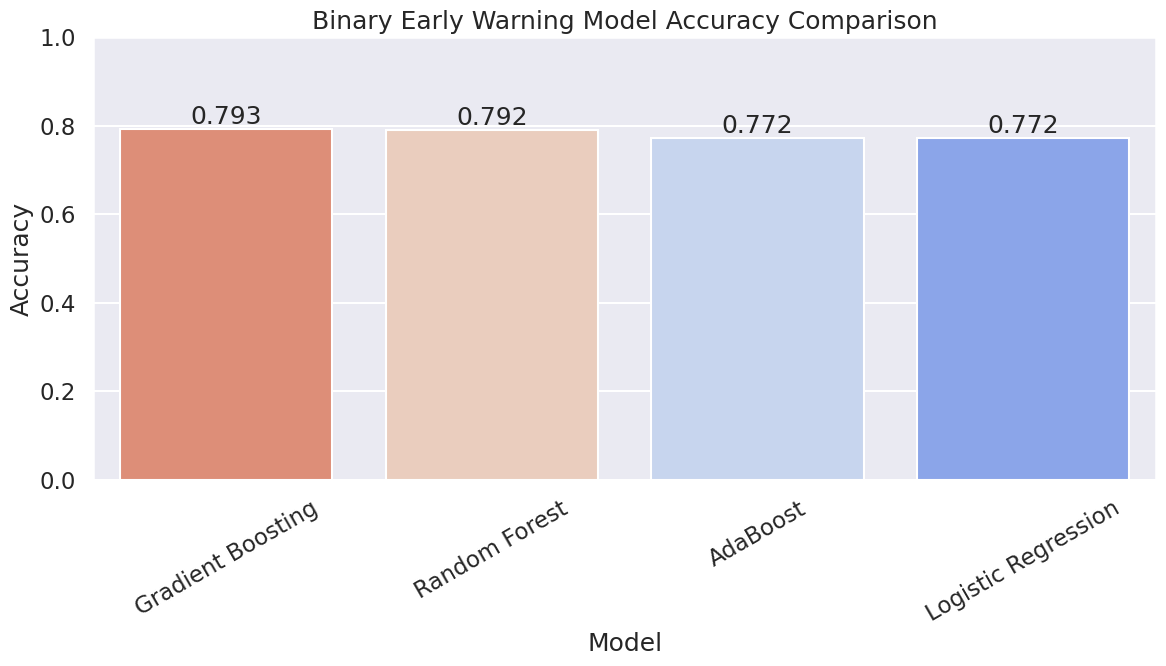

In [ ]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=binary_results_df, x='Model', y='Accuracy', hue='Model', palette = 'coolwarm_r', legend=False)
plt.title('Binary Early Warning Model Accuracy Comparison')
plt.xticks(rotation=30)
plt.ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')
plt.tight_layout()
plt.show()

### Visualization Insight

The graph clearly shows that all models perform better in the binary classification setting.

This reinforces the idea that early warning systems are more reliable when focused on identifying risk rather than exact outcomes.

In [ ]:
best_bin_name = binary_results_df.iloc[0]['Model']
best_bin_model = models_bin[best_bin_name]

best_bin_model.fit(X_train_b, y_train_b)
best_bin_preds = best_bin_model.predict(X_test_b)

print("Best binary model:", best_bin_name)
print(classification_report(y_test_b, best_bin_preds))

cm_bin = confusion_matrix(y_test_b, best_bin_preds)


Best binary model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.75      0.83      0.79      3077
           1       0.83      0.76      0.79      3442

    accuracy                           0.79      6519
   macro avg       0.79      0.79      0.79      6519
weighted avg       0.80      0.79      0.79      6519



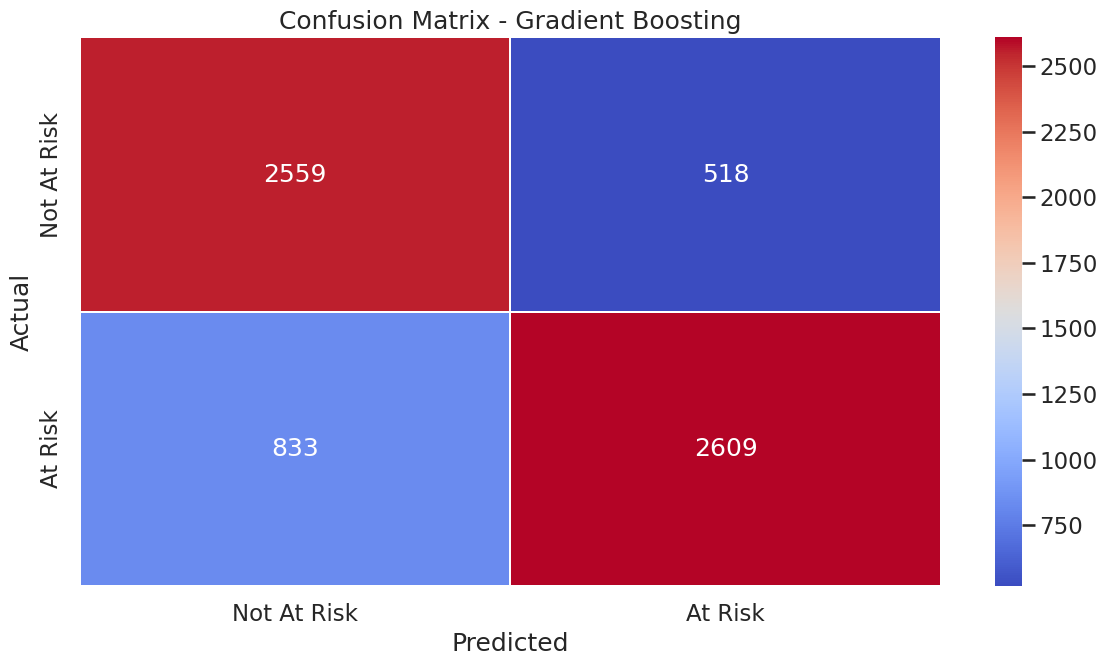

In [ ]:
plt.figure(figsize=(12,7))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='coolwarm',cbar = True,linecolor='white',linewidths=0.1,
            xticklabels=['Not At Risk', 'At Risk'],
            yticklabels=['Not At Risk', 'At Risk'])
plt.title(f'Confusion Matrix - {best_bin_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#### Binary Confusion Matrix Interpretation

The confusion matrix shows that the model performs well in identifying both at-risk and not-at-risk students.

The model correctly identifies a large number of at-risk students, which is critical for early intervention.

However, some at-risk students are still misclassified as safe, which highlights the importance of continuous monitoring.

# Feature Importance

To understand which variables contribute most strongly to student risk prediction, feature importance is extracted from the Random Forest model.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_b, y_train_b)

feature_importance_df = pd.DataFrame({
    'Feature': X_train_b.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

feature_importance_df


,Feature,Importance
7,early_avg_assess_score,0.120016
8,early_max_assess_score,0.098538
6,early_days_active,0.093941
5,early_vle_records,0.089802
3,early_total_clicks,0.089414
4,early_avg_clicks,0.075007
2,date_registration,0.061123
1,studied_credits,0.036637
10,early_num_tma,0.033362
16,code_module_GGG,0.026651


/tmp/ipykernel_3304/4199977614.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature',palette='coolwarm_r')


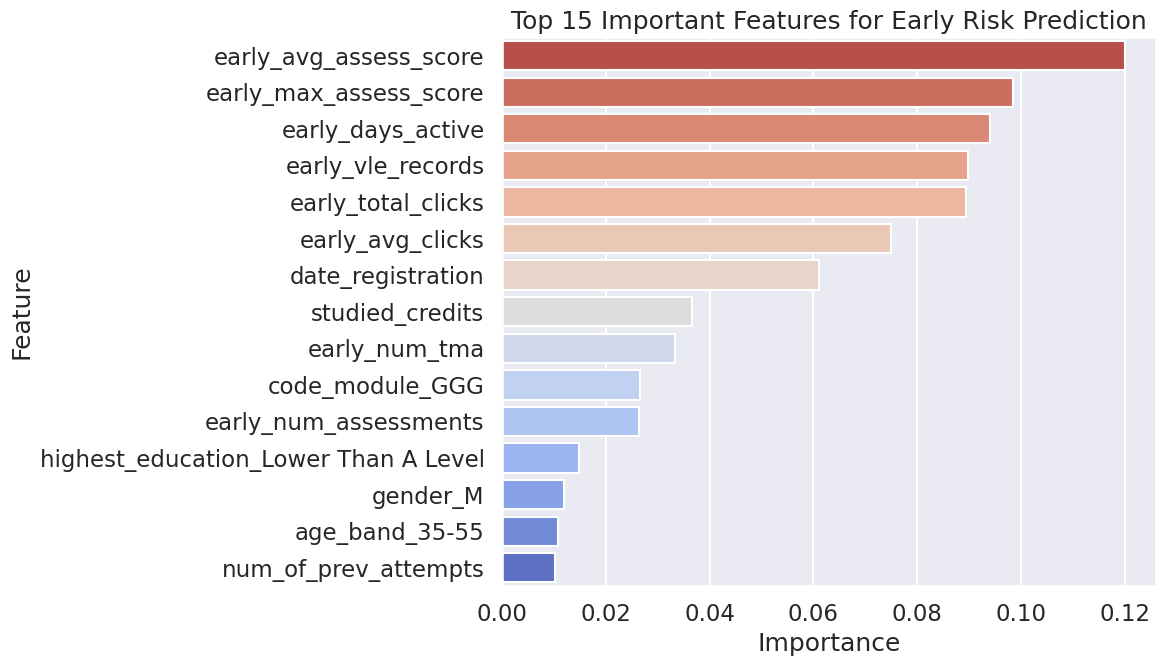

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature',palette='coolwarm_r')
plt.title('Top 15 Important Features for Early Risk Prediction')
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The feature importance results show that early assessment scores and engagement metrics are the strongest predictors of student outcomes.

Variables such as early average assessment score, maximum score, and total clicks in the VLE have the highest importance.

This suggests that student behavior in the early stages of the course is a key indicator of future success or failure.

Demographic variables, such as gender or age, have relatively low importance, indicating that performance is driven more by engagement than by background characteristics.

## Final Machine Learning Insight

The machine learning results demonstrate that student outcomes can be predicted with reasonable accuracy using early-course data.

The multiclass prediction task shows moderate performance, highlighting the difficulty of distinguishing between similar academic outcomes.

In contrast, the binary early warning model achieves higher accuracy, making it more suitable for practical use in identifying at-risk students.

Feature importance analysis confirms that early engagement and assessment performance are the most critical factors.

These findings support the development of early intervention systems that monitor student activity and provide support before academic difficulties become irreversible.

## Limitations

Although the models show promising results, several limitations should be considered.

First, the dataset does not capture all external factors influencing student performance, such as personal motivation, employment status, or internet access.

Second, the accuracy of the multiclass model remains moderate, indicating that predicting exact outcomes is inherently difficult.

Third, early-course features may not fully reflect long-term student behavior, especially for students who improve later in the course.

Finally, machine learning models may contain bias if underlying data reflects socioeconomic or demographic inequalities.

## Practical Implications

The results of this analysis can be directly applied in educational settings.

The binary early warning model can be used to identify at-risk students within the first 20% of the course, allowing instructors to intervene early.

Feature importance results suggest that monitoring early assessment scores and engagement activity is critical.

Institutions can use these insights to build automated alert systems, recommend targeted support, and improve student retention.

This demonstrates how data-driven approaches can enhance learning outcomes in online education environments.